# Visualize Spectrum Reconstructions & Redshift Predictions — Transformer V3 (4096-bin soft-label redshift, v2 tokens)

Load a trained transformer checkpoint (Approach A or B) plus the frozen spectrum tokenizer it was trained with, run it on a handful of DESI spectra, and visualize:

1. **Teacher-forced reconstruction** — predicted spectrum tokens decoded back through the tokenizer
2. **Autoregressive generation** — `model.generate()` from `[SOS]` only, no teacher forcing (the honest visualization)
3. **Redshift prediction** — predicted bin → decoded z value vs true z (scatter)
4. **Per-position token accuracy** — heatmap showing which positions in the sequence the model is good at
5. **Reconstruction error distribution** — per-spectrum MSE histogram

Set the paths in the **Configuration** cell, then run all cells top-to-bottom.

## Imports

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.models.transformer import (
    SpectrumTransformer,
    SOS_TOKEN, EOS_TOKEN,
    SPECTRUM_TOKEN_OFFSET, REDSHIFT_TOKEN_OFFSET, TOTAL_VOCAB_SIZE,
)
from src.tokenizers.spectrum import SpectrumTokenizer, N_TOKENS
from src.tokenizers.redshift import RedshiftTokenizer
from src.training.sequences import tokenize_and_build
from src.utils.data import DESISpectrumDataset

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

## Configuration

**Official release checkpoints** live under `checkpoints/release/` (from W&B project `redshifty`). See `MANIFEST.json` for model IDs and provenance.

```bash
git lfs pull
# or rebuild symlinks from local W&B downloads:
python scripts/setup_release_checkpoints.py
```

Default model: `approach_a_fm_v1_10k_a_ddp4_redmask50_v9` + `spectrum_tokenizer_v1`.

Optional W&B pull cells below are deprecated — use release paths unless re-downloading.

### Settings

In [2]:
# Official release checkpoints (see checkpoints/release/MANIFEST.json)
from src.inference.release import (
    RELEASE_ROOT,
    DEFAULT_TRANSFORMER_ID,
    load_release_models,
    load_manifest,
    get_device,
)

MODEL_ID = 'transformer_v3_4096soft'  # V3 4096-soft
WAVELENGTH_AWARE = True  # tokenizer v2 is wavelength-aware (resample, not legacy stretch)
DATA_DIR = REPO / 'data/desi_raw'
MANIFEST_PATH = None        # optional: training JSONL for z_tok fallback only
APPROACH = None             # auto-detect from checkpoint
N_SAMPLES = 10
SEED = 42
ENCODER_MASK_RATIO = 0.0

manifest = load_manifest()
print(f'Release root: {RELEASE_ROOT}')
print(f'Model ID:     {MODEL_ID}')
print(f'DATA_DIR:     {DATA_DIR}')
print(f'APPROACH:     {APPROACH!r} (auto-detect if None)')

def _require_ckpt():
    from src.inference.release import _checkpoint_path
    try:
        _checkpoint_path(MODEL_ID)
        _checkpoint_path(manifest['models'][MODEL_ID]['requires_tokenizer'])
        return True
    except FileNotFoundError as e:
        print(f'Missing checkpoint: {e}')
        print('  git lfs pull')
        print('  python scripts/setup_release_checkpoints.py')
        return False

HAS_CKPT = _require_ckpt()
HAS_DATA = DATA_DIR.is_dir() and bool(list(DATA_DIR.glob('coadd-*.fits')))
if not HAS_DATA:
    print(f'Note: no FITS in {DATA_DIR} — visualization cells will skip (see data/README.md).')

Release root: /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/checkpoints/release
Model ID:     transformer_v3_4096soft
DATA_DIR:     /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/data/desi_raw
APPROACH:     None (auto-detect if None)


In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'device = {device}')

device = mps


## (Optional) List W&B runs & their model artifacts

Discover what's available before downloading. Lists every run in the project (most recent first) with state, best val loss, and any uploaded model artifacts (with versions and aliases). Copy any artifact URI from the printout into `ARTIFACT_URI` below.

Set `WANDB_ENTITY` to your wandb username; project is `redshifty` by default.

In [ ]:
WANDB_ENTITY = 'jjayaseelan-university-of-san-francisco'  # or None for default entity
WANDB_PROJECT = 'redshifty'
MAX_RUNS = 20

try:
    from dotenv import load_dotenv
    load_dotenv(REPO / '.env')
except ImportError:
    pass
import wandb
api = wandb.Api()
path = f'{WANDB_ENTITY}/{WANDB_PROJECT}' if WANDB_ENTITY else WANDB_PROJECT
runs = api.runs(path, per_page=MAX_RUNS)
print(f'\n=== runs in {path} (most recent first) ===\n')
for r in list(runs)[:MAX_RUNS]:
    best = r.summary.get('val/loss') or r.summary.get('val_loss') or '-'
    print(f'{r.name:50s}  state={r.state:10s}  best_val_loss={best}')
    try:
        arts = list(r.logged_artifacts())
    except Exception as e:
        arts = []
        print(f'    (could not list artifacts: {e})')
    for a in arts:
        if a.type != 'model':
            continue
        uri = f'{a.entity}/{a.project}/{a.name}'
        aliases = ','.join(a.aliases) if a.aliases else ''
        size_mb = a.size / 1e6 if a.size else 0
        print(f'    -> {uri:60s}  aliases=[{aliases}]  {size_mb:.0f} MB')

print('\nCopy a `... /artifact_name:version` URI into ARTIFACT_URI below.')
print('Use :best, :latest, or :v0/:v1/... to pin a specific version.')

## (Optional) Pull checkpoints from W&B Artifacts

Skip the `scp` step entirely by pulling the trained transformer **and/or** the frozen spectrum tokenizer straight from W&B.

- **Transformer** — the Phase-10+ training loop uploads on every best-val step (see `--push-wandb-artifact`). Pick a URI from the run-listing cell above.
- **Spectrum tokenizer** — uploaded once with `nersc/push_tokenizer_artifact.py` (run on NERSC after pretraining finishes). Typical URI: `<entity>/redshifty/spectrum_tokenizer_v1:best`.

Leave a URI as `None` to use the locally-set path instead.

In [ ]:
ARTIFACT_URI           = None  # transformer; e.g. 'jonathansamuel/redshifty/approach_a_<run>:best'
TOKENIZER_ARTIFACT_URI = None  # tokenizer;   e.g. 'jonathansamuel/redshifty/spectrum_tokenizer_v1:best'

if ARTIFACT_URI is not None or TOKENIZER_ARTIFACT_URI is not None:
    try:
        from dotenv import load_dotenv
        load_dotenv(REPO / '.env')
    except ImportError:
        pass
    import wandb
    api = wandb.Api()

    def _pull(uri, label):
        art = api.artifact(uri, type='model')
        dl_dir = REPO / 'checkpoints' / 'wandb_artifacts' / uri.replace('/', '__').replace(':', '@')
        dl_dir.mkdir(parents=True, exist_ok=True)
        art.download(root=str(dl_dir))
        pts = sorted(dl_dir.glob('*.pt'))
        assert pts, f'No .pt file in artifact {uri}'
        print(f'[wandb] {label}: downloaded {uri} -> {pts[0]}')
        return pts[0]

    if ARTIFACT_URI is not None:
        _pull(ARTIFACT_URI, 'transformer')
        print('Re-run: python scripts/setup_release_checkpoints.py')
    if TOKENIZER_ARTIFACT_URI is not None:
        _pull(TOKENIZER_ARTIFACT_URI, 'tokenizer')
        print('Re-run: python scripts/setup_release_checkpoints.py')
else:
    print('[wandb] both URIs None; using checkpoints/release/')

## Load release models

Loads `approach_a_fm_v1_10k_a_ddp4_redmask50_v9` + `spectrum_tokenizer_v1` from `checkpoints/release/`.

In [4]:
if not HAS_CKPT:
    raise RuntimeError('Release checkpoints missing — see Configuration cell.')

model, spec_tok, z_tok, cfg = load_release_models(MODEL_ID, device=device)
ckpt_z_state = None

if APPROACH is None:
    APPROACH = cfg.get('approach', 'a')
print(f"Loaded {cfg.get('display_name', MODEL_ID)}")
print(f'  approach={APPROACH!r}  d_model={cfg.get("d_model")}')
n_params = sum(p.numel() for p in model.parameters())
print(f'  transformer params: {n_params/1e6:.1f}M')
print(f'  z_tok: n_levels={z_tok.n_levels}  range=[{z_tok._min_z:.4f}, {z_tok._max_z:.4f}]')

# The module constant src.tokenizers.spectrum.N_TOKENS (273) is stale — the
# tokenizer actually emits 272 tokens per spectrum (wavelength-aware resampling
# onto a fixed latent grid, independent of input length). Derive the true count
# from a probe encode so every panel below slices/masks the correct width.
with torch.no_grad():
    _probe_idx, _ = spec_tok.encode(torch.zeros(1, 2, 7781, device=device))
N_TOKENS = int(_probe_idx.shape[-1])
print(f'  N_TOKENS (derived from tokenizer) = {N_TOKENS}')


Loaded Spectrum-FM Transformer V3 — 4096-bin soft-label redshift (v2 tokens, X2+X3)
  approach='a'  d_model=768
  transformer params: 103.1M
  z_tok: n_levels=4096  range=[-0.0035, 5.9949]
  N_TOKENS (derived from tokenizer) = 272


## Redshift tokenizer fallback (optional)

Release load already restores `z_tok` from the transformer checkpoint. The cells below only run if that failed.

In [ ]:
if z_tok is not None:
    print('[z_tok] using embedded state from release checkpoint')
elif MANIFEST_PATH is not None and Path(MANIFEST_PATH).is_file():
    from astropy.io import fits
    zs = []
    with open(MANIFEST_PATH) as f:
        for line in f:
            rec = json.loads(line)
            try:
                with fits.open(rec['redrock'], memmap=True) as h:
                    z = h['REDSHIFTS'].data['Z']
                    zwarn = h['REDSHIFTS'].data['ZWARN']
                    zs.append(z[zwarn == 0].astype('float32'))
            except Exception as e:
                print(f'  skip {rec["redrock"]}: {e}')
    zs = torch.from_numpy(np.concatenate(zs))
    z_tok = RedshiftTokenizer(n_levels=256)
    z_tok.fit(zs)
    print(f'[z_tok] fit from manifest  n={len(zs)}  '
          f'range=[{zs.min():.4f}, {zs.max():.4f}]')

## Load spectra to visualize

Reuses `DESISpectrumDataset` from `src/utils/data.py` to load FITS files from `DATA_DIR`. If `z_tok` is still uninitialized at this point, fits it on these spectra as a last resort (and prints a warning).

In [9]:
if not HAS_DATA:
    print(f'No FITS in {DATA_DIR}. Downloading 2 healpix tiles...')
    import subprocess
    subprocess.run(
        [sys.executable, str(REPO / 'scripts/download_desi_batch.py'), '--n-files', '2'],
        check=False, cwd=str(REPO),
    )
    HAS_DATA = DATA_DIR.is_dir() and bool(list(DATA_DIR.glob('coadd-*.fits')))
    if not HAS_DATA:
        raise RuntimeError(
            f'No FITS in {DATA_DIR}. Run from repo root:\n'
            '  python scripts/download_desi_batch.py --n-files 2'
        )
coadd_files = sorted(DATA_DIR.glob('coadd-*.fits'))
print(f'Found {len(coadd_files)} coadd files in {DATA_DIR}')

spectra = []
for f in coadd_files:
    rr = f.parent / f.name.replace('coadd-', 'redrock-')
    if not rr.exists():
        print(f'  skip {f.name}: no redrock counterpart')
        continue
    ds = DESISpectrumDataset(
        coadd_path=f, redrock_path=rr,
        require_good_zwarn=True, require_nonzero_flux=True,
    )
    for i in range(len(ds)):
        spectra.append(ds[i])
print(f'Loaded {len(spectra)} good spectra')

if z_tok is None:
    print('\n*** WARNING: z_tok was not loaded from checkpoint or manifest. ***')
    print('*** Fitting on local FITS spectra. Predicted z values may be miscalibrated ***')
    print('*** relative to what the trained model expects. ***\n')
    z_values_fallback = torch.tensor([float(s['z']) for s in spectra])
    z_tok = RedshiftTokenizer(n_levels=256)
    z_tok.fit(z_values_fallback)
    print(f'[z_tok] fit from local FITS  n={len(z_values_fallback)}')

print(f'\n[z_tok] in use: n_levels={z_tok.n_levels}  '
      f'range=[{z_tok._min_z:.4f}, {z_tok._max_z:.4f}]')

Found 2 coadd files in /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/data/desi_raw
  Filtered out 18 bad spectra:
    18 bad fiber status
Loaded 25 good spectra from coadd-sv3-bright-10016.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
  Filtered out 1 bad spectra:
    1 bad ZWARN
Loaded 4 good spectra from coadd-sv3-bright-10145.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
Loaded 29 good spectra

[z_tok] in use: n_levels=4096  range=[-0.0035, 5.9949]


## Pick samples to visualize

In [6]:
rng = torch.Generator().manual_seed(SEED)
idx = torch.randperm(len(spectra), generator=rng)[:N_SAMPLES].tolist()
sample_specs = [spectra[i] for i in idx]
for i, s in enumerate(sample_specs):
    print(f'  sample {i}: z={float(s["z"]):+.4f}  L={len(s["flux"])} pixels')

  sample 0: z=+0.1146  L=7781 pixels
  sample 1: z=+0.3228  L=7781 pixels
  sample 2: z=+0.1153  L=7781 pixels
  sample 3: z=+0.2007  L=7781 pixels
  sample 4: z=+0.9900  L=7781 pixels
  sample 5: z=+0.2766  L=7781 pixels
  sample 6: z=+0.3083  L=7781 pixels
  sample 7: z=-0.0001  L=7781 pixels
  sample 8: z=+0.2466  L=7781 pixels
  sample 9: z=-0.0008  L=7781 pixels


## Helpers

In [12]:
def specs_to_batch(spec_list):
    """Pad a list of spectrum dicts to a uniform tensor batch."""
    L = max(s['flux'].shape[0] for s in spec_list)
    def _pad(t, fill=0.0):
        if t.shape[0] == L: return t
        out = torch.full((L,), fill, dtype=t.dtype)
        out[:t.shape[0]] = t
        return out
    return {
        'flux': torch.stack([_pad(s['flux']) for s in spec_list]),
        'ivar': torch.stack([_pad(s['ivar'], 0.0) for s in spec_list]),
        'z':    torch.stack([s['z'] for s in spec_list]).float(),
        'wavelength': torch.stack([s['wavelength'] for s in spec_list]),
    }

@torch.no_grad()
def predict_teacher_forced(batch, approach):
    """Returns (enc, dec, target, predicted_tokens, denorm). predicted_tokens
    has the same shape as target — model's argmax at every decoder position."""
    enc, dec, tgt, _ = tokenize_and_build(
        batch, spec_tok, z_tok, approach, device, wavelength_aware=WAVELENGTH_AWARE, encoder_mask_ratio=ENCODER_MASK_RATIO,
    )
    logits, _ = model(enc, dec, targets=tgt)
    pred = logits.argmax(dim=-1)
    flux = batch['flux'].to(device)
    ivar = batch['ivar'].to(device)
    istd = torch.sqrt(ivar.clamp(min=1e-10))
    x = torch.stack([flux, istd], dim=1)
    _, denorm = spec_tok.encode(x, wavelength=(batch['wavelength'].to(device) if WAVELENGTH_AWARE else None))
    return enc, dec, tgt, pred, denorm

@torch.no_grad()
def predict_autoregressive(batch, approach, temperature=1.0):
    enc, _, tgt, _ = tokenize_and_build(
        batch, spec_tok, z_tok, approach, device, wavelength_aware=WAVELENGTH_AWARE, encoder_mask_ratio=ENCODER_MASK_RATIO,
    )
    L_dec = tgt.shape[1]
    generated = model.generate(
        enc, decoder_start_token=SOS_TOKEN, max_new_tokens=L_dec,
        temperature=temperature,
    )
    return generated, tgt

def decode_to_flux(spec_token_ids, denorm):
    """Map global vocab token IDs (with SPECTRUM_TOKEN_OFFSET) back through
    the spectrum tokenizer to a continuous flux array. Invalid token IDs
    (SOS/EOS/MASK leakage) are mapped to LFQ index 0 so decode doesn't crash."""
    lfq_idx = spec_token_ids - SPECTRUM_TOKEN_OFFSET
    valid = (lfq_idx >= 0) & (lfq_idx < 1024)
    lfq_idx = torch.where(valid, lfq_idx, torch.zeros_like(lfq_idx))
    decoded = spec_tok.decode(lfq_idx, denorm)
    return decoded[:, 0]  # flux channel

# ── Spectral line marker ──────────────────────────────────────────────────────
EMISSION_LINES = {
    'Lyα':        1216,
    '[OII]':      3727,
    'Hδ':         4102,
    'Hγ':         4340,
    'Hβ':         4861,
    '[OIII]4959': 4959,
    '[OIII]5007': 5007,
    'Hα':         6563,
    '[NII]':      6583,
    '[SII]':      6717,
}
ABSORPTION_LINES = {
    'CaK':  3934,
    'CaH':  3968,
    'G':    4300,
    'Mgb':  5175,
    'NaD':  5893,
    'CaT':  8542,
}

def mark_lines(ax, z, wave_lo, wave_hi, wave_to_x=None, ypos=0.97, fontsize=6.5):
    """Overlay redshifted emission (green dashed) and absorption (orange dotted) lines.

    wave_lo/wave_hi : observed wavelength limits (Angstrom) for visibility check.
    wave_to_x       : converts observed wavelength to x-axis units; None = wavelength IS x.
    """
    if wave_to_x is None:
        wave_to_x = lambda w: w
    trans = ax.get_xaxis_transform()   # x in data coords, y in axes [0,1]
    for label, lam in EMISSION_LINES.items():
        obs = lam * (1 + z)
        if not (wave_lo <= obs <= wave_hi):
            continue
        x = wave_to_x(obs)
        ax.axvline(x, color='green', lw=0.6, ls='--', alpha=0.45)
        ax.text(x, ypos, label, transform=trans, fontsize=fontsize,
                color='green', rotation=90, va='top', ha='right', alpha=0.85)
    for label, lam in ABSORPTION_LINES.items():
        obs = lam * (1 + z)
        if not (wave_lo <= obs <= wave_hi):
            continue
        x = wave_to_x(obs)
        ax.axvline(x, color='darkorange', lw=0.6, ls=':', alpha=0.45)
        ax.text(x, ypos, label, transform=trans, fontsize=fontsize,
                color='darkorange', rotation=90, va='top', ha='right', alpha=0.85)


# Physical wavelength axis (tokenizer v2 grid).
# Decoded flux lives on the model's fixed 8704-px grid: index i <-> wavelength
# GRID_WAVE_MIN + GRID_WAVE_STEP*i (3500-10462.4 A @ 0.8 A, AION convention).
# DESI only covers 3600-9824 A; the resampler ZERO-FILLS the grid outside that,
# so the flat tails at the blue/red ends are *expected*, not a model failure.
from src.tokenizers.spectrum import GRID_WAVE_MIN, GRID_WAVE_STEP, GRID_WAVE_MAX
DESI_WAVE_LO, DESI_WAVE_HI = 3600.0, 9824.0  # DESI native coverage

def wave_axis(n):
    """Observed-wavelength (A) coordinate for an n-pixel decoded-flux array."""
    return GRID_WAVE_MIN + GRID_WAVE_STEP * np.arange(n)

def shade_uncovered(ax, lo=DESI_WAVE_LO, hi=DESI_WAVE_HI):
    """Grey out the grid outside DESI coverage; flux there is zero-filled by the
    wavelength-aware resampler (expected, not a reconstruction failure)."""
    ax.axvspan(GRID_WAVE_MIN, lo, color='lightgray', alpha=0.4, lw=0)
    ax.axvspan(hi, GRID_WAVE_MAX, color='lightgray', alpha=0.4, lw=0)


# Spectrum-plot x-axis styling: show ONLY the DESI 3600-9824 A range (hide the
# zero-filled v2-grid tails) and label exact wavelengths.
WAVE_TICKS = [3600, 4000, 5000, 6000, 7000, 8000, 9000, 9824]

def style_wave_axes(fig, ticks=WAVE_TICKS):
    """Clip every axis in `fig` to the DESI range and tick exact wavelengths (Å);
    only the bottom axis gets tick labels."""
    for ax in fig.axes:
        ax.set_xlim(DESI_WAVE_LO, DESI_WAVE_HI)
        ax.set_xticks(ticks)
        ax.set_xticklabels([])
    fig.axes[-1].set_xticklabels([str(int(t)) for t in ticks], fontsize=7)


## Visualization 1 — Teacher-forced reconstruction

Each row: one sample. Black = original (after tokenizer roundtrip); orange = decoded from the model's predicted tokens. Teacher-forced means the decoder saw the ground-truth tokens at every position before the one it predicted, so this is the **best-case** reconstruction (and the most copy-inflated).

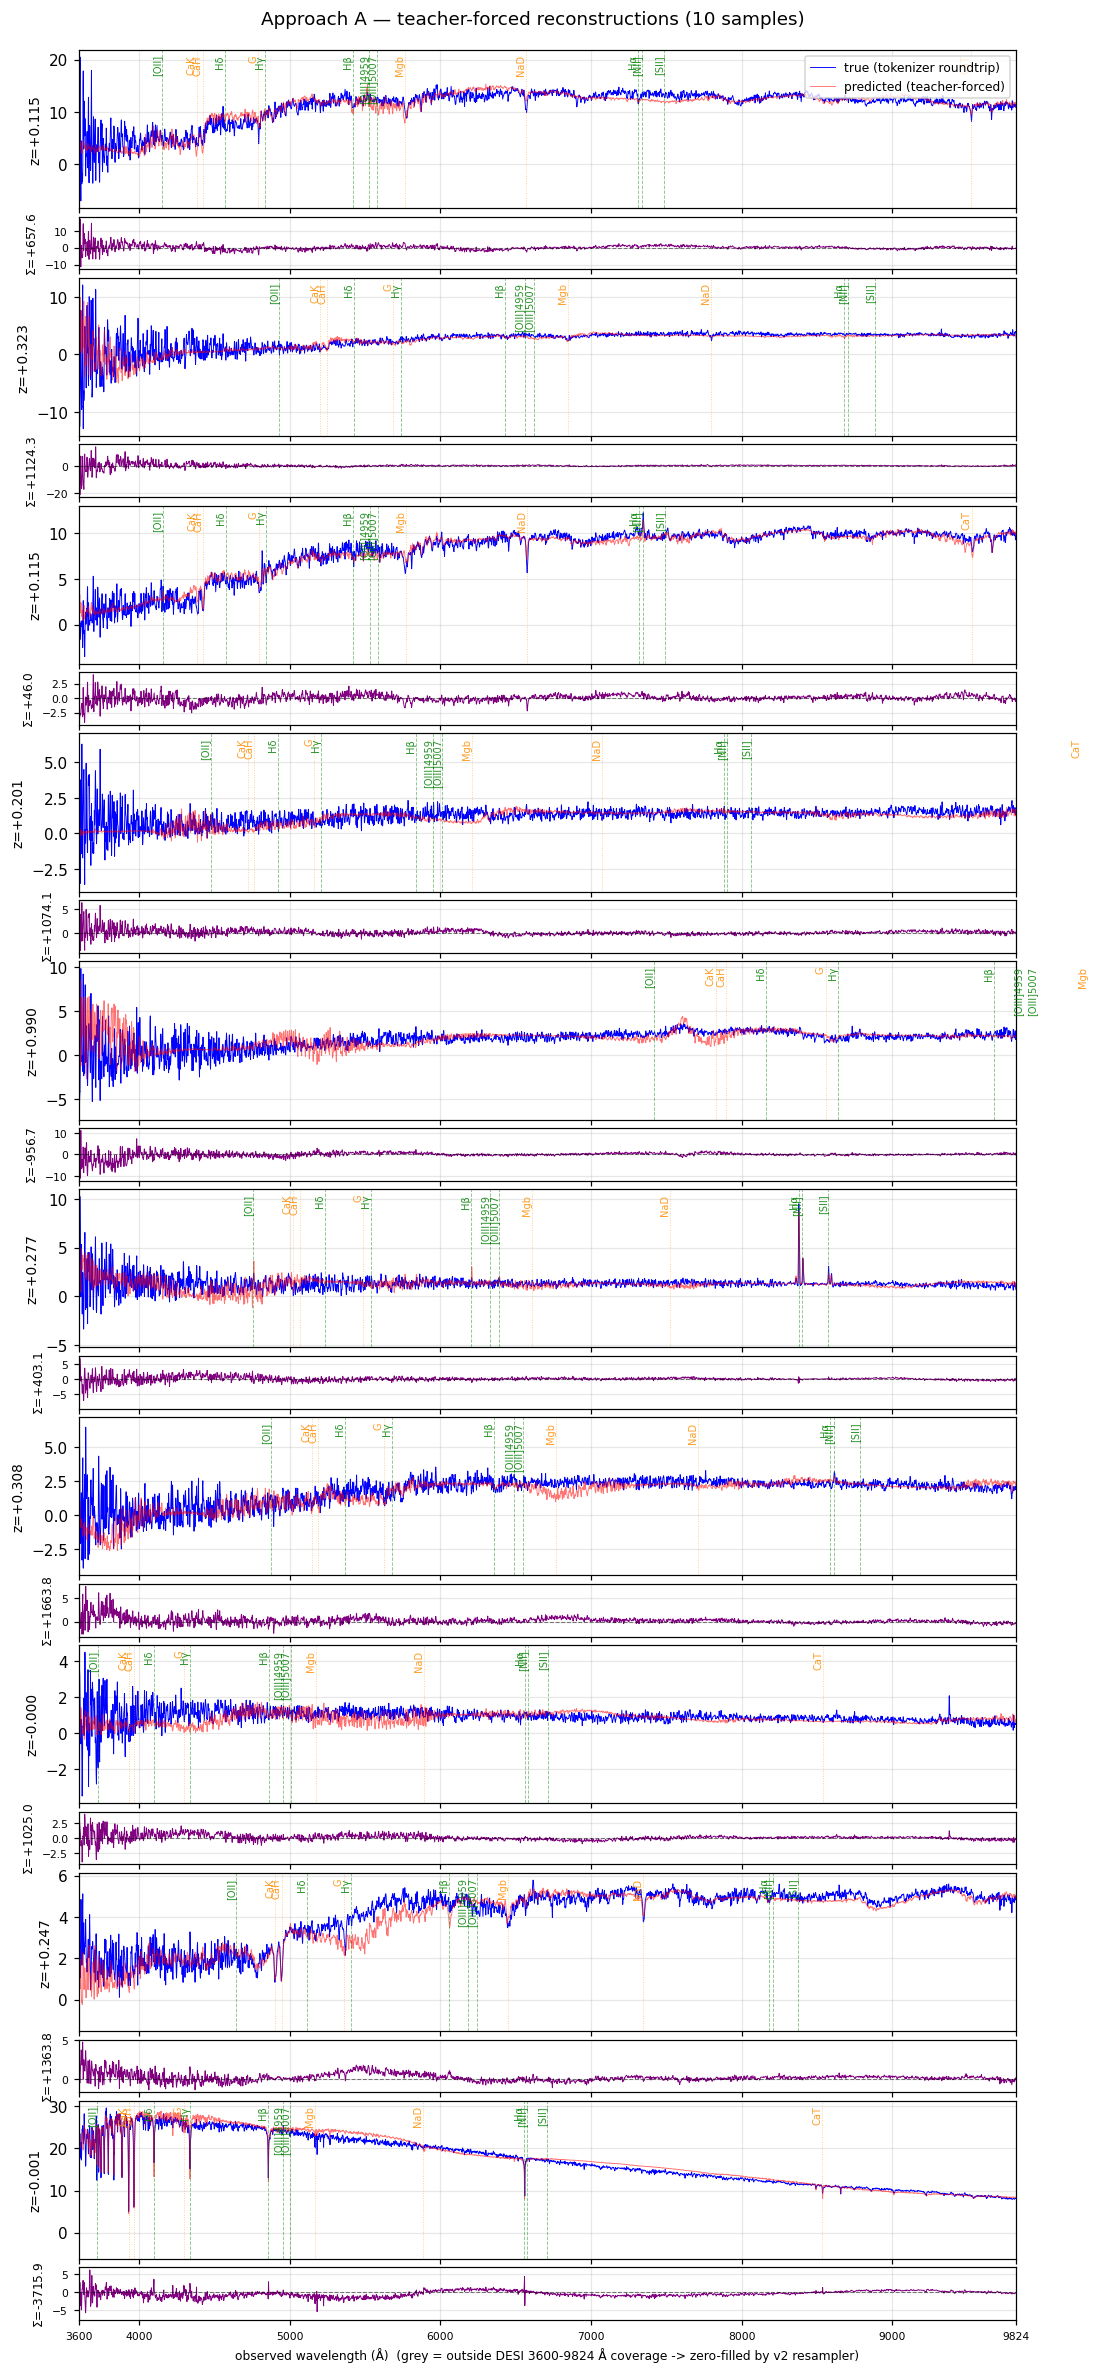

In [8]:
batch = specs_to_batch(sample_specs)
enc, dec, tgt, pred, denorm = predict_teacher_forced(batch, APPROACH)

pred_spec_tokens = pred[:, 1:1 + N_TOKENS]
true_spec_tokens = tgt[:, 1:1 + N_TOKENS]

pred_flux = decode_to_flux(pred_spec_tokens, denorm).cpu().numpy()
true_flux = decode_to_flux(true_spec_tokens, denorm).cpu().numpy()

# 2 rows per sample: flux row (height 3) + residual row (height 1)
height_ratios = [h for _ in range(N_SAMPLES) for h in (3, 1)]
fig, axes = plt.subplots(
    N_SAMPLES * 2, 1, figsize=(11, 2.4 * N_SAMPLES),
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08}, sharex=True,
)
for i in range(N_SAMPLES):
    ax_f = axes[i * 2]      # flux row
    ax_r = axes[i * 2 + 1]  # residual row

    resid = true_flux[i] - pred_flux[i]
    z = float(sample_specs[i]['z'])
    _dec_len = true_flux.shape[1]
    wx = wave_axis(_dec_len)

    # --- flux row ---
    ax_f.plot(wx, true_flux[i], color='blue', lw=0.6, label='true (tokenizer roundtrip)')
    ax_f.plot(wx, pred_flux[i], color='red', lw=0.6, alpha=0.55, label='predicted (teacher-forced)')
    shade_uncovered(ax_f)
    mark_lines(ax_f, z, GRID_WAVE_MIN, GRID_WAVE_MAX)
    ax_f.set_ylabel(f'z={z:+.3f}', fontsize=9)
    ax_f.set_xticklabels([])
    ax_f.grid(alpha=0.3)
    if i == 0:
        ax_f.legend(loc='upper right', fontsize=8)

    # --- residual row (data - reconstruction) ---
    ax_r.plot(wx, resid, color='purple', lw=0.6)
    ax_r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ax_r.set_ylabel(f'$\\Sigma$={resid.sum():+.1f}', fontsize=8, labelpad=4)
    ax_r.grid(alpha=0.3)
    ax_r.tick_params(axis='y', labelsize=7)
    if i < N_SAMPLES - 1:
        ax_r.set_xticklabels([])

axes[-1].set_xlabel('observed wavelength (Å)  (grey = outside DESI 3600-9824 Å coverage -> zero-filled by v2 resampler)', fontsize=8)
fig.subplots_adjust(top=0.97)
fig.suptitle(f'Approach {APPROACH.upper()} — teacher-forced reconstructions ({N_SAMPLES} samples)',
             y=0.985)
style_wave_axes(fig)
plt.show()

## Visualization 2 — Autoregressive generation

Same samples, but generated token-by-token starting from `[SOS]` only. **No peeking at the answer.** This is the honest reconstruction — if it looks similar to teacher-forced, the model really learned. If it diverges, the teacher-forced number was inflated by the cross-attention copy.

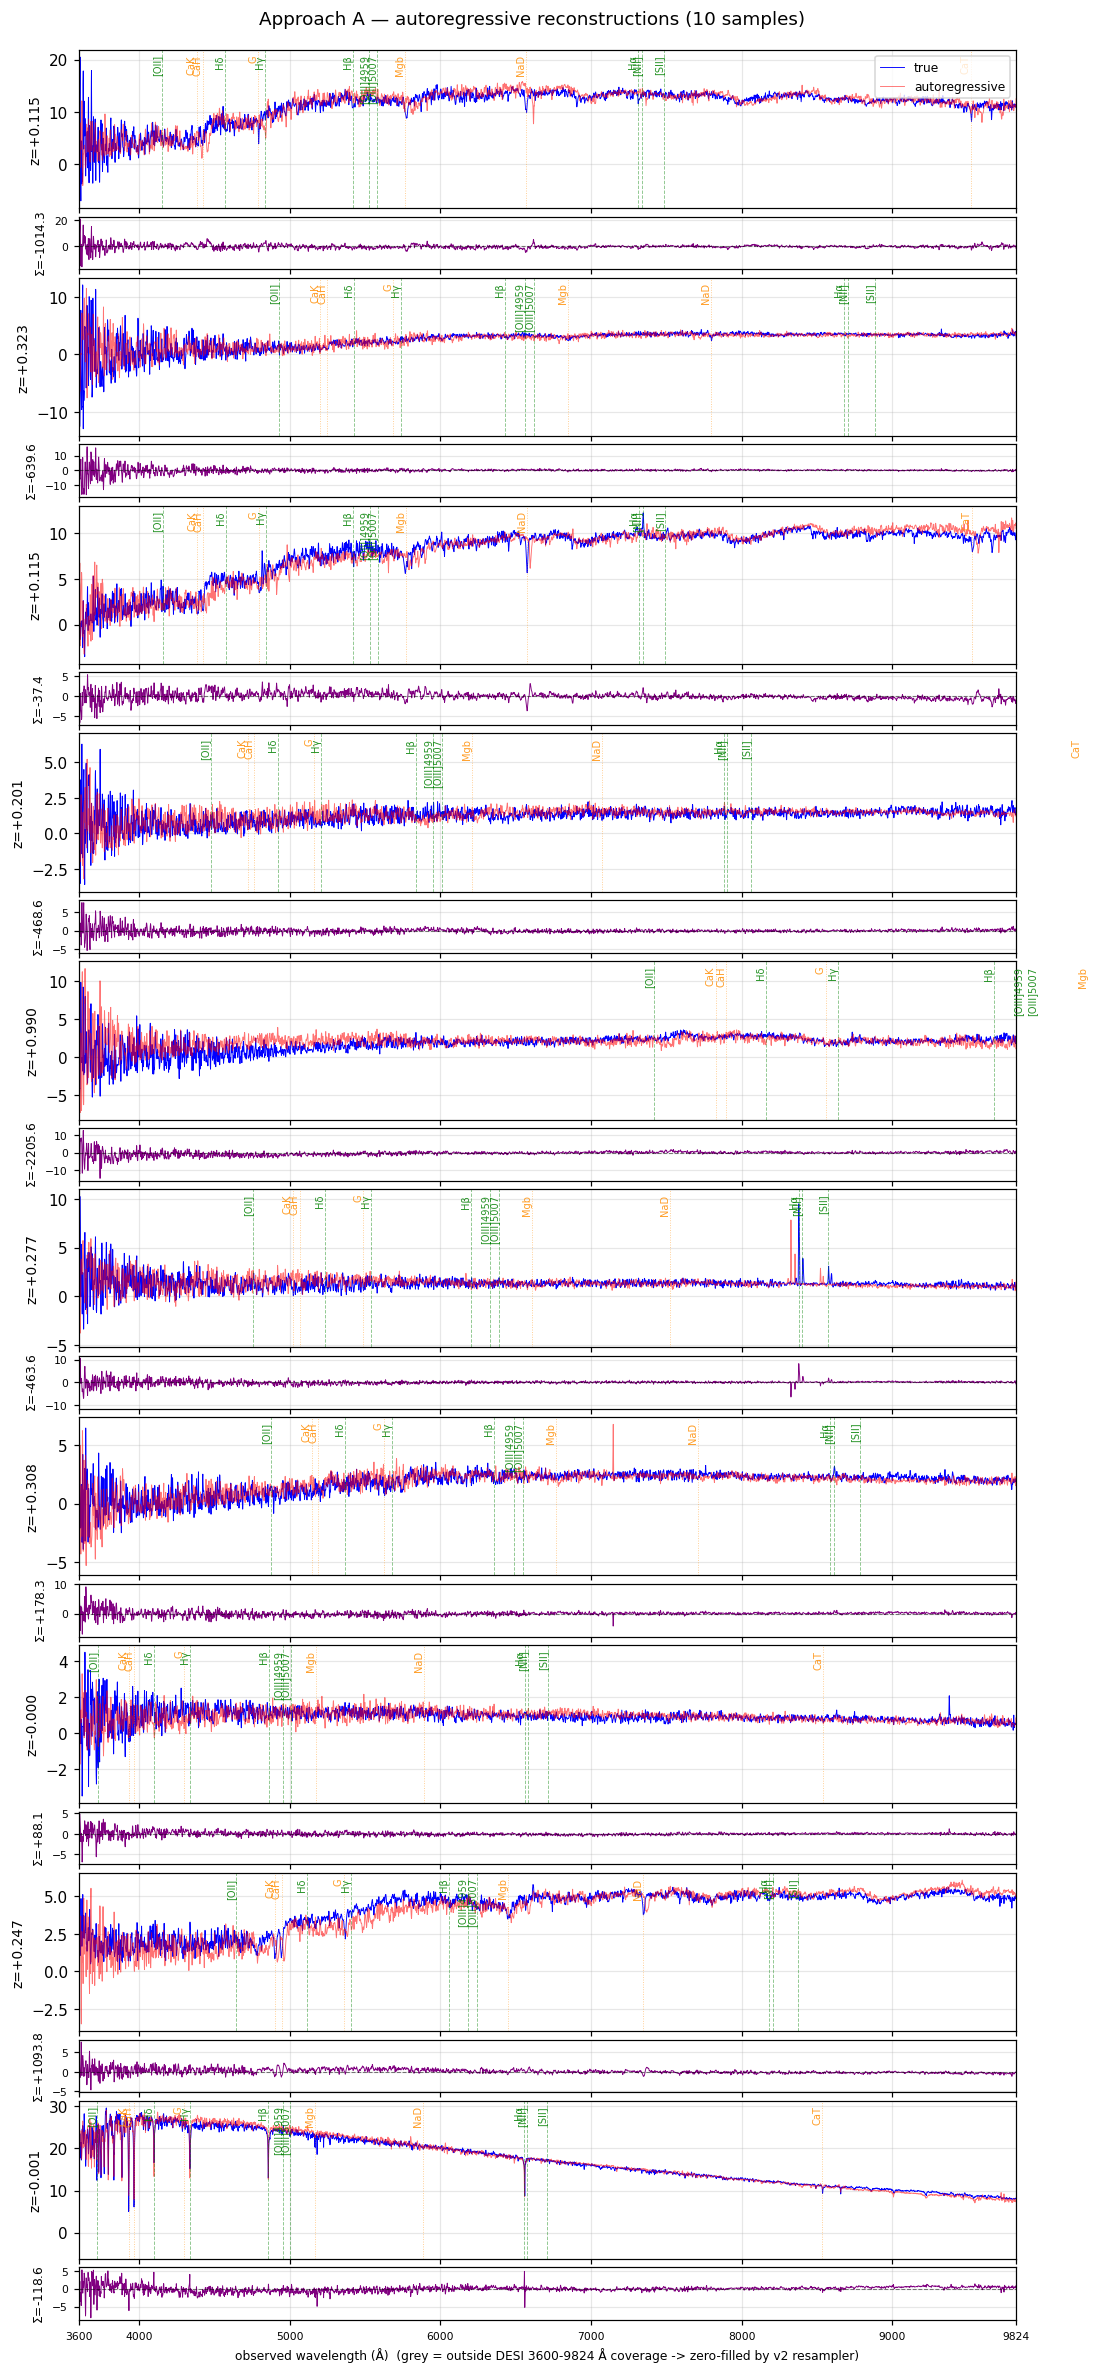

In [9]:
generated, tgt_ar = predict_autoregressive(batch, APPROACH, temperature=1.0)
ar_spec_tokens = generated[:, 2:2 + N_TOKENS]
# Pad if generate stopped early on EOS
if ar_spec_tokens.shape[1] < N_TOKENS:
    pad_len = N_TOKENS - ar_spec_tokens.shape[1]
    pad = torch.full((ar_spec_tokens.shape[0], pad_len), SPECTRUM_TOKEN_OFFSET,
                     dtype=torch.long, device=device)
    ar_spec_tokens = torch.cat([ar_spec_tokens, pad], dim=1)

ar_flux = decode_to_flux(ar_spec_tokens, denorm).cpu().numpy()

# 2 rows per sample: flux row (height 3) + residual row (height 1)
height_ratios = [h for _ in range(N_SAMPLES) for h in (3, 1)]
fig, axes = plt.subplots(
    N_SAMPLES * 2, 1, figsize=(11, 2.4 * N_SAMPLES),
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08}, sharex=True,
)
for i in range(N_SAMPLES):
    ax_f = axes[i * 2]      # flux row
    ax_r = axes[i * 2 + 1]  # residual row

    resid = true_flux[i] - ar_flux[i]
    z = float(sample_specs[i]['z'])
    _dec_len = ar_flux.shape[1]
    wx = wave_axis(_dec_len)

    # --- flux row ---
    ax_f.plot(wx, true_flux[i], color='blue', lw=0.6, label='true')
    ax_f.plot(wx, ar_flux[i], color='red', lw=0.6, alpha=0.55, label='autoregressive')
    shade_uncovered(ax_f)
    mark_lines(ax_f, z, GRID_WAVE_MIN, GRID_WAVE_MAX)
    ax_f.set_ylabel(f'z={z:+.3f}', fontsize=9)
    ax_f.set_xticklabels([])
    ax_f.grid(alpha=0.3)
    if i == 0:
        ax_f.legend(loc='upper right', fontsize=8)

    # --- residual row (data - reconstruction) ---
    ax_r.plot(wx, resid, color='purple', lw=0.6)
    ax_r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ax_r.set_ylabel(f'$\\Sigma$={resid.sum():+.1f}', fontsize=8, labelpad=4)
    ax_r.grid(alpha=0.3)
    ax_r.tick_params(axis='y', labelsize=7)
    if i < N_SAMPLES - 1:
        ax_r.set_xticklabels([])

axes[-1].set_xlabel('observed wavelength (Å)  (grey = outside DESI 3600-9824 Å coverage -> zero-filled by v2 resampler)', fontsize=8)
fig.subplots_adjust(top=0.97)
fig.suptitle(f'Approach {APPROACH.upper()} — autoregressive reconstructions ({N_SAMPLES} samples)',
             y=0.985)
style_wave_axes(fig)
plt.show()

## Visualization 2b — Blind reconstruction (masked encoder + hidden redshift)

Visualization 2 was autoregressive on the *decoder* side, but the **encoder still saw the full spectrum** (`ENCODER_MASK_RATIO = 0.0`), so the decoder could reconstruct by copying it through cross-attention — and for Approach A the true redshift sat in the encoder too. So that panel is really a best-case *copy* demo.

This panel removes the crutch: **50% of the encoder's spectrum tokens are replaced with `[MASK]`** and the **redshift token is hidden** (`[REDMASK]`, Approach A). The model must now *infer* the missing spectrum tokens and the redshift from partial context only — the genuinely honest "predict without info" reconstruction. Expect a visibly larger residual than Visualization 2; how much larger **is** the size of the copy shortcut. (The v9 model was trained with `redmask50`, so hiding z is in-distribution.)


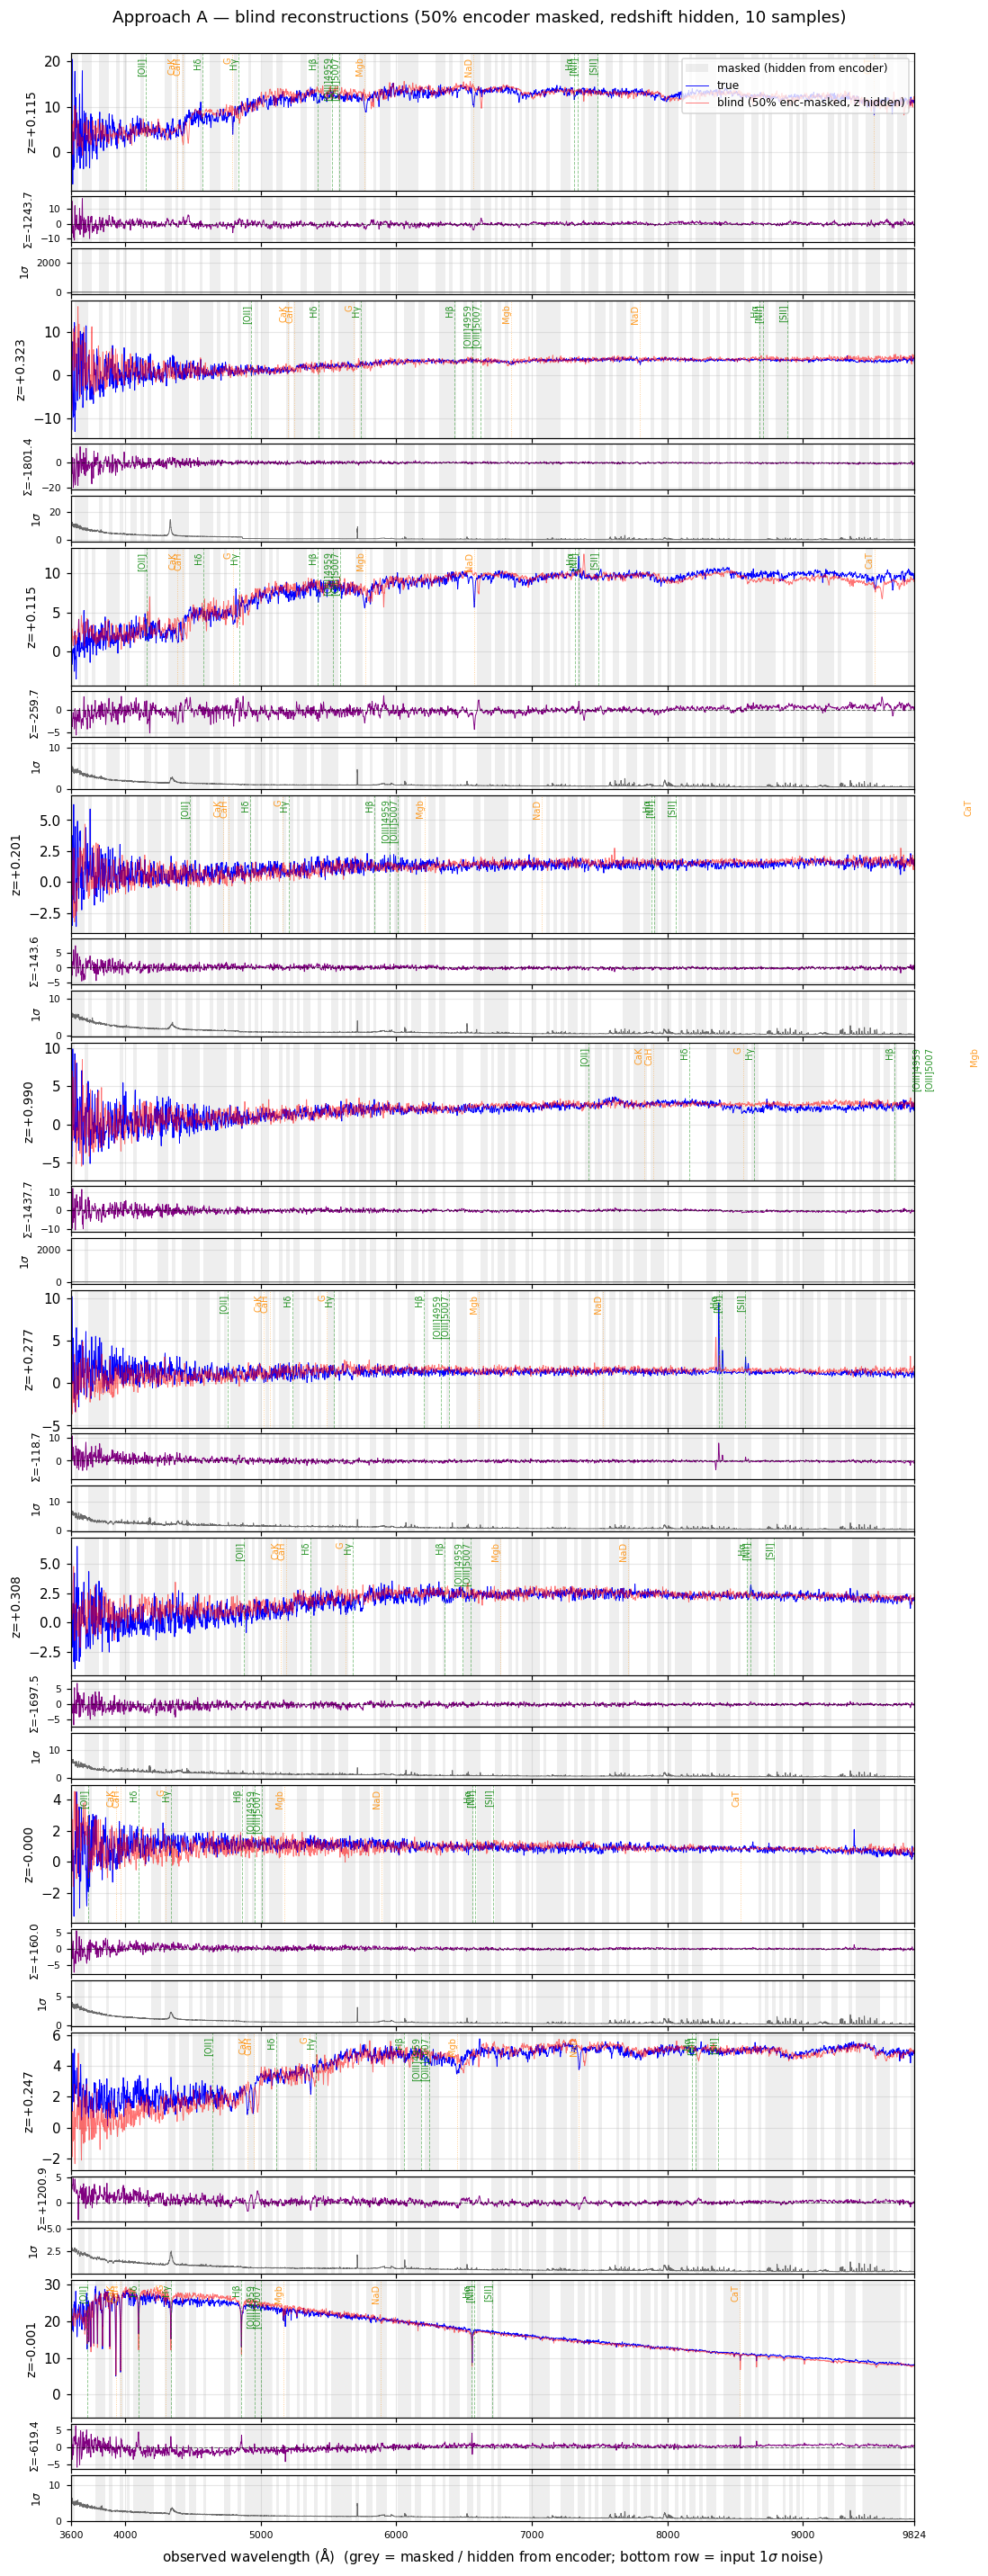

blind MSE = 0.9433  (encoder 50% masked, redshift hidden)
  on masked  (inferred) regions = 0.9408
  on visible (anchor)   regions = 0.9456


In [10]:
BLIND_MASK_RATIO = 0.5   # fraction of encoder spectrum tokens hidden from the model

@torch.no_grad()
def predict_autoregressive_blind(batch, approach, mask_ratio=BLIND_MASK_RATIO,
                                 hide_redshift=True, temperature=1.0, seed=SEED):
    """Autoregressive generation with the encoder spectrum partly masked and
    (Approach A) the redshift token hidden, so the masked positions are absent
    from the encoder and must be *inferred* rather than copied via
    cross-attention. Returns (generated, target, masked_positions)."""
    torch.manual_seed(seed)  # reproducible mask draw, device-agnostic
    enc, _, tgt, mask_pos = tokenize_and_build(
        batch, spec_tok, z_tok, approach, device,
        wavelength_aware=WAVELENGTH_AWARE,
        encoder_mask_ratio=mask_ratio,
        redshift_mask_ratio=(1.0 if (hide_redshift and approach == 'a') else 0.0),
    )
    L_dec = tgt.shape[1]
    generated = model.generate(
        enc, decoder_start_token=SOS_TOKEN, max_new_tokens=L_dec,
        temperature=temperature,
    )
    return generated, tgt, mask_pos


blind_generated, blind_tgt, blind_mask = predict_autoregressive_blind(batch, APPROACH)
blind_spec_tokens = blind_generated[:, 2:2 + N_TOKENS]
# Pad if generate stopped early on EOS
if blind_spec_tokens.shape[1] < N_TOKENS:
    pad_len = N_TOKENS - blind_spec_tokens.shape[1]
    pad = torch.full((blind_spec_tokens.shape[0], pad_len), SPECTRUM_TOKEN_OFFSET,
                     dtype=torch.long, device=device)
    blind_spec_tokens = torch.cat([blind_spec_tokens, pad], dim=1)
blind_flux = decode_to_flux(blind_spec_tokens, denorm).cpu().numpy()

mask_frac = blind_mask.float().mean().item() if blind_mask is not None else 0.0

# token -> flux-pixel map for shading hidden vs visible regions
_L = blind_flux.shape[1]
blind_mask_np = (blind_mask.cpu().numpy().astype(bool) if blind_mask is not None
                 else np.zeros((blind_flux.shape[0], N_TOKENS), bool))
_n_mask_tok = blind_mask_np.shape[1]          # actual masked-token count (T_spec)
_tok_of_x = np.minimum(np.arange(_L) * _n_mask_tok // _L, _n_mask_tok - 1)

# Per-pixel 1-sigma noise = 1/sqrt(ivar), in the same physical-flux units as the
# decoded flux. nan where there is no measurement (ivar<=0) so the line breaks;
# nearest-index resample keeps those gaps aligned with the flux/residual x-axis.
ivar_np = batch['ivar'].cpu().numpy()
_src_idx = np.linspace(0, ivar_np.shape[1] - 1, _L).round().astype(int)

# 3 rows per sample: flux (3) + residual (1) + noise (1)
height_ratios = [h for _ in range(N_SAMPLES) for h in (3, 1, 1)]
fig, axes = plt.subplots(
    N_SAMPLES * 3, 1, figsize=(11, 2.9 * N_SAMPLES),
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08}, sharex=True,
)
for i in range(N_SAMPLES):
    ax_f = axes[i * 3]      # flux row
    ax_r = axes[i * 3 + 1]  # residual row
    ax_n = axes[i * 3 + 2]  # noise row

    resid = true_flux[i] - blind_flux[i]
    z = float(sample_specs[i]['z'])
    _dec_len = blind_flux.shape[1]
    wx = wave_axis(_dec_len)

    # Shade hidden (masked) regions on all three rows; un-shaded = visible.
    masked_x = blind_mask_np[i][_tok_of_x]
    for ax in (ax_f, ax_r, ax_n):
        ax.fill_between(wx, 0, 1, where=masked_x,
                        transform=ax.get_xaxis_transform(), step='mid',
                        color='gray', alpha=0.13, linewidth=0,
                        label='masked (hidden from encoder)' if (i == 0 and ax is ax_f) else None)

    # --- flux row ---
    ax_f.plot(wx, true_flux[i], color='blue', lw=0.6, label='true')
    ax_f.plot(wx, blind_flux[i], color='red', lw=0.6, alpha=0.55,
              label=f'blind ({mask_frac:.0%} enc-masked, z hidden)')
    shade_uncovered(ax_f)
    mark_lines(ax_f, z, GRID_WAVE_MIN, GRID_WAVE_MAX)
    ax_f.set_ylabel(f'z={z:+.3f}', fontsize=9)
    ax_f.set_xticklabels([])
    ax_f.grid(alpha=0.3)
    if i == 0:
        ax_f.legend(loc='upper right', fontsize=8)

    # --- residual row (data - reconstruction) ---
    ax_r.plot(wx, resid, color='purple', lw=0.6)
    ax_r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ax_r.set_ylabel(f'$\\Sigma$={resid.sum():+.1f}', fontsize=8, labelpad=4)
    ax_r.grid(alpha=0.3)
    ax_r.tick_params(axis='y', labelsize=7)
    ax_r.set_xticklabels([])

    # --- noise row (1-sigma uncertainty from ivar) ---
    iv = ivar_np[i]
    sig = np.full(iv.shape, np.nan)
    pos = iv > 0
    sig[pos] = 1.0 / np.sqrt(iv[pos])
    ax_n.plot(wx, sig[_src_idx], color='dimgray', lw=0.6)
    ax_n.set_ylabel('1$\\sigma$', fontsize=8, labelpad=4)
    ax_n.grid(alpha=0.3)
    ax_n.tick_params(axis='y', labelsize=7)
    if i < N_SAMPLES - 1:
        ax_n.set_xticklabels([])

axes[-1].set_xlabel('observed wavelength (Å)  '
                    '(grey = masked / hidden from encoder; bottom row = input 1$\\sigma$ noise)')
fig.subplots_adjust(top=0.97)
fig.suptitle(f'Approach {APPROACH.upper()} — blind reconstructions '
             f'({mask_frac:.0%} encoder masked, redshift hidden, {N_SAMPLES} samples)',
             y=0.985)
style_wave_axes(fig)
plt.show()

# Headline: blind MSE + masked(inferred)/visible(anchor) split.
blind_mse = ((torch.from_numpy(true_flux) - torch.from_numpy(blind_flux)) ** 2).mean(axis=1)
_sq = (true_flux - blind_flux) ** 2
_mask_x_all = blind_mask_np[:, _tok_of_x]   # (N_SAMPLES, L) bool
print(f'blind MSE = {blind_mse.mean():.4f}  '
      f'(encoder {mask_frac:.0%} masked, redshift hidden)')
print(f'  on masked  (inferred) regions = {_sq[_mask_x_all].mean():.4f}')
print(f'  on visible (anchor)   regions = {_sq[~_mask_x_all].mean():.4f}')


## Visualization 2c — Blind reconstruction at 90% masking

Push it to the limit: only **10% of the encoder's spectrum tokens survive** (90% replaced with `[MASK]`), redshift still hidden. This is close to near-unconditional generation — the model has almost nothing left to copy, so it must lean on what it learned about the data manifold. A model that genuinely learned the spectra still produces plausible continuum and line structure from the 10% of anchors; a copy-reliant one collapses. Expect the largest residual of the three panels — the 50%→90% degradation curve is the real picture of how much the model knows vs. copies.


In [ ]:
BLIND_MASK_RATIO_HI = 0.9   # only 10% of encoder spectrum tokens survive

blind90_generated, _, blind90_mask = predict_autoregressive_blind(
    batch, APPROACH, mask_ratio=BLIND_MASK_RATIO_HI)
blind90_spec_tokens = blind90_generated[:, 2:2 + N_TOKENS]
# Pad if generate stopped early on EOS
if blind90_spec_tokens.shape[1] < N_TOKENS:
    pad_len = N_TOKENS - blind90_spec_tokens.shape[1]
    pad = torch.full((blind90_spec_tokens.shape[0], pad_len), SPECTRUM_TOKEN_OFFSET,
                     dtype=torch.long, device=device)
    blind90_spec_tokens = torch.cat([blind90_spec_tokens, pad], dim=1)
blind90_flux = decode_to_flux(blind90_spec_tokens, denorm).cpu().numpy()

mask_frac90 = blind90_mask.float().mean().item() if blind90_mask is not None else 0.0

# token -> flux-pixel map for shading hidden vs visible regions
_L90 = blind90_flux.shape[1]
blind90_mask_np = (blind90_mask.cpu().numpy().astype(bool) if blind90_mask is not None
                   else np.zeros((blind90_flux.shape[0], N_TOKENS), bool))
_n_mask_tok90 = blind90_mask_np.shape[1]
_tok_of_x90 = np.minimum(np.arange(_L90) * _n_mask_tok90 // _L90, _n_mask_tok90 - 1)

# Per-pixel 1-sigma noise = 1/sqrt(ivar); nan where ivar<=0; nearest-index
# resample aligns it with the flux/residual x-axis.
ivar_np = batch['ivar'].cpu().numpy()
_src_idx90 = np.linspace(0, ivar_np.shape[1] - 1, _L90).round().astype(int)

# 3 rows per sample: flux (3) + residual (1) + noise (1)
height_ratios = [h for _ in range(N_SAMPLES) for h in (3, 1, 1)]
fig, axes = plt.subplots(
    N_SAMPLES * 3, 1, figsize=(11, 2.9 * N_SAMPLES),
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08}, sharex=True,
)
for i in range(N_SAMPLES):
    ax_f = axes[i * 3]      # flux row
    ax_r = axes[i * 3 + 1]  # residual row
    ax_n = axes[i * 3 + 2]  # noise row

    resid = true_flux[i] - blind90_flux[i]
    z = float(sample_specs[i]['z'])
    _dec_len = blind90_flux.shape[1]
    wx = wave_axis(_dec_len)

    # Shade hidden (masked) regions on all three rows; un-shaded = visible (~10% anchors).
    masked_x = blind90_mask_np[i][_tok_of_x90]
    for ax in (ax_f, ax_r, ax_n):
        ax.fill_between(wx, 0, 1, where=masked_x,
                        transform=ax.get_xaxis_transform(), step='mid',
                        color='gray', alpha=0.13, linewidth=0,
                        label='masked (hidden from encoder)' if (i == 0 and ax is ax_f) else None)

    # --- flux row ---
    ax_f.plot(wx, true_flux[i], color='blue', lw=0.6, label='true')
    ax_f.plot(wx, blind90_flux[i], color='red', lw=0.6, alpha=0.55,
              label=f'blind ({mask_frac90:.0%} enc-masked, z hidden)')
    shade_uncovered(ax_f)
    mark_lines(ax_f, z, GRID_WAVE_MIN, GRID_WAVE_MAX)
    ax_f.set_ylabel(f'z={z:+.3f}', fontsize=9)
    ax_f.set_xticklabels([])
    ax_f.grid(alpha=0.3)
    if i == 0:
        ax_f.legend(loc='upper right', fontsize=8)

    # --- residual row (data - reconstruction) ---
    ax_r.plot(wx, resid, color='purple', lw=0.6)
    ax_r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ax_r.set_ylabel(f'$\\Sigma$={resid.sum():+.1f}', fontsize=8, labelpad=4)
    ax_r.grid(alpha=0.3)
    ax_r.tick_params(axis='y', labelsize=7)
    ax_r.set_xticklabels([])

    # --- noise row (1-sigma uncertainty from ivar) ---
    iv = ivar_np[i]
    sig = np.full(iv.shape, np.nan)
    pos = iv > 0
    sig[pos] = 1.0 / np.sqrt(iv[pos])
    ax_n.plot(wx, sig[_src_idx90], color='dimgray', lw=0.6)
    ax_n.set_ylabel('1$\\sigma$', fontsize=8, labelpad=4)
    ax_n.grid(alpha=0.3)
    ax_n.tick_params(axis='y', labelsize=7)
    if i < N_SAMPLES - 1:
        ax_n.set_xticklabels([])

axes[-1].set_xlabel('observed wavelength (Å)  '
                    '(grey = masked / hidden from encoder; bottom row = input 1$\\sigma$ noise)')
fig.subplots_adjust(top=0.97)
fig.suptitle(f'Approach {APPROACH.upper()} — blind reconstructions '
             f'({mask_frac90:.0%} encoder masked, redshift hidden, {N_SAMPLES} samples)',
             y=0.985)
style_wave_axes(fig)
plt.show()

# Degradation curve + masked(inferred)/visible(anchor) split.
blind90_mse = ((torch.from_numpy(true_flux) - torch.from_numpy(blind90_flux)) ** 2).mean(axis=1)
_sq90 = (true_flux - blind90_flux) ** 2
_mask_x_all90 = blind90_mask_np[:, _tok_of_x90]   # (N_SAMPLES, L) bool
print(f'blind MSE @ {mask_frac:.0%} masked = {blind_mse.mean():.4f}')
print(f'blind MSE @ {mask_frac90:.0%} masked = {blind90_mse.mean():.4f}')
print(f'  @ {mask_frac90:.0%}: masked (inferred) = {_sq90[_mask_x_all90].mean():.4f}   '
      f'visible (anchor) = {_sq90[~_mask_x_all90].mean():.4f}')
print('Compare both against the Viz 5 autoregressive MSE (0% encoder masked).')


## Visualization 3 — Redshift predictions

Predicted bin → decoded z (via the empirical-CDF inverse). **Three series:**

- **teacher-forced / autoregressive** — both run with the redshift token *visible* in the encoder (`redshift_mask_ratio=0.0`). For Approach A the model can copy z straight out of the encoder via cross-attention, so these are near-perfect but measure *copy fidelity, not inference*.
- **blind (z hidden)** — from the Viz 2b cell, where the encoder's redshift token is `[REDMASK]`. This is the **honest spectrum→z** number: the model has to infer redshift from the spectrum alone (what the v9 `redmask50` training prepared it for). This is the one that actually says whether the model learned redshift.

For Approach B the encoder never carries a redshift token, so all three coincide.


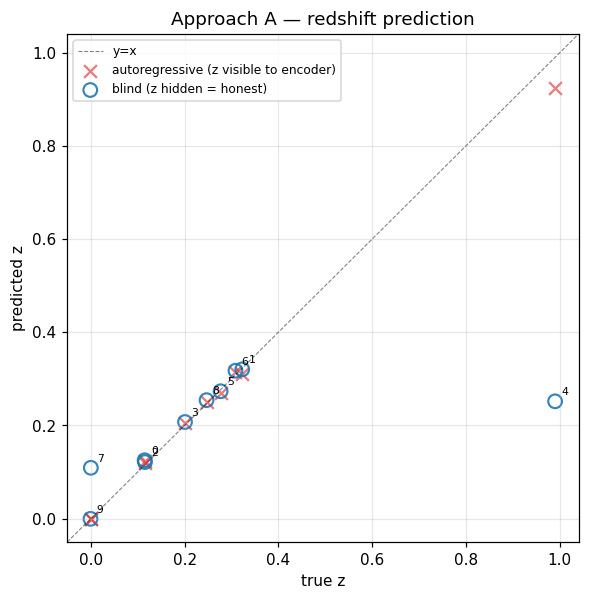


teacher-forced   MAE = 0.0008  (z copied from encoder)
autoregressive   MAE = 0.0111  (z copied from encoder)
blind (z hidden) MAE = 0.0893  <- honest spectrum->z

Per-sample:
  0: z_true=+0.1146  tf=+0.1144  ar=+0.1230  blind=+0.1251
  1: z_true=+0.3228  tf=+0.3216  ar=+0.3106  blind=+0.3202
  2: z_true=+0.1153  tf=+0.1148  ar=+0.1198  blind=+0.1212
  3: z_true=+0.2007  tf=+0.2004  ar=+0.2040  blind=+0.2072
  4: z_true=+0.9900  tf=+0.9860  ar=+0.9243  blind=+0.2515
  5: z_true=+0.2766  tf=+0.2768  ar=+0.2686  blind=+0.2732
  6: z_true=+0.3083  tf=+0.3091  ar=+0.3137  blind=+0.3172
  7: z_true=-0.0001  tf=-0.0001  ar=-0.0001  blind=+0.1089
  8: z_true=+0.2466  tf=+0.2472  ar=+0.2501  blind=+0.2540
  9: z_true=-0.0008  tf=-0.0008  ar=-0.0008  blind=-0.0007


In [11]:
tf_z_token  = pred[:, 0].cpu()
tf_z_idx    = (tf_z_token - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
tf_z_pred   = torch.tensor([z_tok.decode(int(i)) for i in tf_z_idx])

ar_z_token  = generated[:, 1].cpu()
ar_z_idx    = (ar_z_token - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
ar_z_pred   = torch.tensor([z_tok.decode(int(i)) for i in ar_z_idx])

# Blind: redshift was hidden from the encoder ([REDMASK], Viz 2b), so this is
# the honest spectrum->z inference — unlike tf/ar above, which for Approach A
# copy the true redshift token straight out of the encoder via cross-attention.
blind_z_token = blind_generated[:, 1].cpu()
blind_z_idx   = (blind_z_token - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
blind_z_pred  = torch.tensor([z_tok.decode(int(i)) for i in blind_z_idx])

z_true = torch.stack([s['z'] for s in sample_specs]).float()

fig, ax = plt.subplots(figsize=(6, 6))
_all = torch.cat([z_true, tf_z_pred, ar_z_pred, blind_z_pred])
lim_lo = _all.min().item() - 0.05
lim_hi = _all.max().item() + 0.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=0.7, alpha=0.5, label='y=x')
# ax.scatter(z_true, tf_z_pred, s=70, alpha=0.75, label='teacher-forced', c='C1')
ax.scatter(z_true, ar_z_pred, s=70, alpha=0.6, marker='x',
           label='autoregressive (z visible to encoder)', c='C3')
ax.scatter(z_true, blind_z_pred, s=80, alpha=0.9, marker='o', facecolors='none',
           edgecolors='C0', linewidths=1.4, label='blind (z hidden = honest)')
for i in range(len(z_true)):
    ax.annotate(str(i), (z_true[i], blind_z_pred[i]), fontsize=7,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('true z')
ax.set_ylabel('predicted z')
ax.set_title(f'Approach {APPROACH.upper()} — redshift prediction')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
plt.show()

print(f'\nteacher-forced   MAE = {(tf_z_pred - z_true).abs().mean():.4f}  (z copied from encoder)')
print(f'autoregressive   MAE = {(ar_z_pred - z_true).abs().mean():.4f}  (z copied from encoder)')
print(f'blind (z hidden) MAE = {(blind_z_pred - z_true).abs().mean():.4f}  <- honest spectrum->z')
print(f'\nPer-sample:')
for i in range(len(z_true)):
    print(f'  {i}: z_true={z_true[i]:+.4f}  tf={tf_z_pred[i]:+.4f}  '
          f'ar={ar_z_pred[i]:+.4f}  blind={blind_z_pred[i]:+.4f}')


## Visualization 4 — Per-position token accuracy

Across the batch, fraction of correct token predictions at each decoder position. Position 0 = redshift; positions 1..N = spectrum tokens. A model relying on the trivial copy shortcut will be near-flat at high accuracy on positions 1+ but near-zero at position 0.

In [ ]:
tf_correct = (pred == tgt).float().mean(dim=0).cpu().numpy()
ar_overlap_len = min(generated.shape[1] - 1, tgt.shape[1])
ar_correct = (generated[:, 1:1 + ar_overlap_len] == tgt[:, :ar_overlap_len]).float().mean(dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(tf_correct, label='teacher-forced', color='C1', lw=1.0)
ax.plot(ar_correct, label='autoregressive', color='C3', lw=1.0, alpha=0.8)
ax.axvspan(0, 0.5, alpha=0.15, color='C0', label='redshift token (pos 0)')
ax.set_xlabel('decoder position')
ax.set_ylabel('fraction correct across batch')
ax.set_title(f'Approach {APPROACH.upper()} — per-position prediction accuracy')
ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Visualization 5 — Reconstruction error distribution

Per-spectrum MSE between original (tokenizer-roundtripped) and predicted flux. The AR/TF ratio is the headline — `~1.0` means the model really learned; `>>1` means teacher-forcing was carrying it.

In [ ]:
tf_mse = ((torch.from_numpy(true_flux) - torch.from_numpy(pred_flux))**2).mean(dim=1).numpy()
ar_mse = ((torch.from_numpy(true_flux) - torch.from_numpy(ar_flux))**2).mean(dim=1).numpy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(tf_mse, bins=20, alpha=0.6, label=f'teacher-forced (mean={tf_mse.mean():.3f})', color='C1')
ax.hist(ar_mse, bins=20, alpha=0.6, label=f'autoregressive  (mean={ar_mse.mean():.3f})', color='C3')
ax.set_xlabel('per-spectrum MSE')
ax.set_ylabel('count')
ax.set_title('Reconstruction error distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f'TF MSE: mean={tf_mse.mean():.3f}, median={np.median(tf_mse):.3f}, max={tf_mse.max():.3f}')
print(f'AR MSE: mean={ar_mse.mean():.3f}, median={np.median(ar_mse):.3f}, max={ar_mse.max():.3f}')
print(f'AR/TF ratio: {ar_mse.mean()/max(tf_mse.mean(), 1e-9):.2f}x  '
      f'(1.0 = identical; >>1 = AR much worse → copy shortcut)')

---
## OOD Probe — SDSS Spectra (Out-of-Distribution)

Load 10 SDSS DR17 spectra from [MultimodalUniverse/sdss](https://huggingface.co/datasets/MultimodalUniverse/sdss) and run the trained model on them. SDSS and DESI share broad wavelength coverage but differ in:

| | SDSS | DESI |
|---|---|---|
| Wavelength | ~3700–10,000 Å (log-λ) | 3600–9824 Å (linear) |
| Resolution | R ~ 2,000 | R ~ 3,000–5,000 |
| Fiber diameter | 3″ | 1.5″ |

Spectra are linearly interpolated onto the DESI grid before being passed through the tokenizer and transformer. Wavelength coverage gaps are filled with zero flux / zero ivar.

**Three OOD visualizations follow (autoregressive only):**
- **Viz 6** — AR reconstructions of SDSS spectra
- **Viz 7** — AR redshift prediction scatter on SDSS
- **Viz 8** — AR MSE comparison: DESI (in-dist) vs SDSS (OOD)

In [6]:
N_OOD = 10
SDSS_POOL_N = 100   # larger pool streamed once; reconstruction panels use the
                    # first N_OOD, the redshift metric uses the whole pool.
MAX_MASK_FRAC = 0.10  # skip spectra with >10% masked pixels (bad CCD / cosmic rays)

try:
    from datasets import load_dataset
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets', '-q'])
    from datasets import load_dataset

# Use the file-system shm strategy: more robust against fd-limit "Broken pipe"
# errors from the dataset's torch-backed streaming loader. NOTE: if you still
# hit "Broken pipe", a *previous* failed stream killed this kernel's torch
# shared-memory manager — Restart the Kernel and Run All (this cell streams only
# once, so it won't recur).
import torch.multiprocessing as _tmp
try:
    _tmp.set_sharing_strategy('file_system')
except Exception:
    pass

print('Streaming SDSS spectra from MultimodalUniverse/sdss ...')
sdss_ds = load_dataset(
    'MultimodalUniverse/sdss',
    split='train',
    streaming=True,
    trust_remote_code=False,
)

# Stream ONCE into a pool of up to SDSS_POOL_N. (Re-creating a second streaming
# dataset elsewhere can raise a multiprocessing "Broken pipe" — so everything
# downstream reuses this pool instead of streaming again.)
sdss_pool = []
n_skipped_z = 0
n_skipped_mask = 0
for row in sdss_ds:
    if row['ZWARNING']:
        n_skipped_z += 1
        continue
    z = float(row['Z'])
    if not (0.01 <= z <= 5.0):
        n_skipped_z += 1
        continue
    mask_frac = np.array(row['spectrum']['mask'], dtype=bool).mean()
    if mask_frac > MAX_MASK_FRAC:
        n_skipped_mask += 1
        continue
    sdss_pool.append(row)
    if len(sdss_pool) >= SDSS_POOL_N:
        break

sdss_raw = sdss_pool[:N_OOD]   # subset used by the row-per-sample panels
print(f'Collected {len(sdss_pool)} SDSS spectra  '
      f'(first {len(sdss_raw)} drive the reconstruction panels; '
      f'skipped {n_skipped_z} bad-z, {n_skipped_mask} high-mask-frac >{MAX_MASK_FRAC:.0%})')
for i, r in enumerate(sdss_raw):
    s = r['spectrum']
    lam = s['lambda']
    mf = np.array(s['mask'], dtype=bool).mean()
    print(f'  sdss {i}: z={r["Z"]:.4f}  '
          f'λ=[{min(lam):.0f}, {max(lam):.0f}] Å  '
          f'n={len(s["flux"])} px  mask={mf:.1%}')


Streaming SDSS spectra from MultimodalUniverse/sdss ...
Collected 100 SDSS spectra  (first 10 drive the reconstruction panels; skipped 11 bad-z, 13 high-mask-frac >10%)
  sdss 0: z=0.1026  λ=[3788, 9221] Å  n=3865 px  mask=1.8%
  sdss 1: z=0.0622  λ=[3788, 9221] Å  n=3865 px  mask=1.9%
  sdss 2: z=0.1919  λ=[3788, 9221] Å  n=3865 px  mask=1.7%
  sdss 3: z=0.0800  λ=[3788, 9221] Å  n=3865 px  mask=2.0%
  sdss 4: z=0.1521  λ=[3788, 9221] Å  n=3865 px  mask=1.2%
  sdss 5: z=0.0436  λ=[3788, 9221] Å  n=3865 px  mask=0.4%
  sdss 6: z=0.0322  λ=[3788, 9221] Å  n=3865 px  mask=1.7%
  sdss 7: z=0.1355  λ=[3788, 9221] Å  n=3865 px  mask=2.2%
  sdss 8: z=0.1492  λ=[3788, 9221] Å  n=3865 px  mask=2.5%
  sdss 9: z=0.0743  λ=[3788, 9221] Å  n=3865 px  mask=1.6%


In [13]:
from scipy.interpolate import interp1d

desi_wave = spectra[0]['wavelength'].numpy()  # (7781,) Å, linear
sdss_wave = np.array(sdss_raw[0]['spectrum']['lambda'], dtype=np.float32)  # SDSS native log-λ grid

def resample_sdss(row):
    """Resample a MultimodalUniverse SDSS row to the DESI wavelength grid."""
    s = row['spectrum']
    flux = np.array(s['flux'], dtype=np.float32)
    ivar = np.array(s['ivar'], dtype=np.float32)
    mask = np.array(s['mask'], dtype=bool)
    wave = np.array(s['lambda'], dtype=np.float32)
    flux[mask] = 0.0
    ivar[mask] = 0.0
    f_flux = interp1d(wave, flux, bounds_error=False, fill_value=0.0)
    f_ivar = interp1d(wave, ivar, bounds_error=False, fill_value=0.0)
    return {
        'flux': torch.from_numpy(f_flux(desi_wave).astype(np.float32)),
        'ivar': torch.from_numpy(f_ivar(desi_wave).astype(np.float32)),
        'z':    torch.tensor(float(row['Z']), dtype=torch.float32),
        'wavelength': torch.from_numpy(desi_wave.copy()),
    }

ood_specs = [resample_sdss(r) for r in sdss_raw]
print(f'Resampled {len(ood_specs)} SDSS spectra to DESI grid ({len(desi_wave)} px, '
      f'{desi_wave[0]:.0f}–{desi_wave[-1]:.0f} Å)')
print(f'SDSS native grid: {len(sdss_wave)} px, {sdss_wave[0]:.0f}–{sdss_wave[-1]:.0f} Å')

ood_batch = specs_to_batch(ood_specs)

# Compute denorm for decode (no forward pass needed)
with torch.no_grad():
    _flux = ood_batch['flux'].to(device)
    _ivar = ood_batch['ivar'].to(device)
    _istd = torch.sqrt(_ivar.clamp(min=1e-10))
    _x = torch.stack([_flux, _istd], dim=1)
    _, ood_denorm = spec_tok.encode(_x, wavelength=(ood_batch['wavelength'].to(device) if WAVELENGTH_AWARE else None))

# Autoregressive predictions — also returns the target sequence
ood_generated, ood_tgt = predict_autoregressive(ood_batch, APPROACH, temperature=1.0)

# True flux: same 273-token slice used by the in-distribution DESI code,
# so true and AR decode to identical-length arrays with no resampling.
ood_true_spec_tokens = ood_tgt[:, 1:1 + N_TOKENS]          # (B, 273)
ood_true_flux = decode_to_flux(ood_true_spec_tokens, ood_denorm).cpu().numpy()

# AR flux: 273 tokens, same decode length as true
ood_ar_spec_tokens = ood_generated[:, 2:2 + N_TOKENS]       # (B, 273)
if ood_ar_spec_tokens.shape[1] < N_TOKENS:
    pad_len = N_TOKENS - ood_ar_spec_tokens.shape[1]
    pad = torch.full((ood_ar_spec_tokens.shape[0], pad_len), SPECTRUM_TOKEN_OFFSET,
                     dtype=torch.long, device=device)
    ood_ar_spec_tokens = torch.cat([ood_ar_spec_tokens, pad], dim=1)
ood_ar_flux = decode_to_flux(ood_ar_spec_tokens, ood_denorm).cpu().numpy()

# Both arrays are now the same length — build one shared wavelength grid
assert ood_true_flux.shape == ood_ar_flux.shape,     f"shape mismatch: {ood_true_flux.shape} vs {ood_ar_flux.shape}"
ref_wave = wave_axis(ood_true_flux.shape[1])  # model grid 3500-10462.4 Å (decoded flux spans the full v2 grid, not just DESI 3600-9824)

# Zero true flux outside SDSS coverage (tokenizer roundtrip creates small artifacts in zero-padded edges)
_outside = (ref_wave < max(float(sdss_wave[0]), DESI_WAVE_LO)) | (ref_wave > min(float(sdss_wave[-1]), DESI_WAVE_HI))
ood_true_flux[:, _outside] = 0.0

def to_sdss_grid(flux_1d):
    """Resample a ref_wave-grid flux array onto sdss_wave."""
    return interp1d(ref_wave, flux_1d, bounds_error=False, fill_value=0.0)(sdss_wave)

print(f'ood_true_flux shape: {ood_true_flux.shape}  ood_ar_flux shape: {ood_ar_flux.shape}')
print(f'ref_wave: {len(ref_wave)} px, {ref_wave[0]:.1f}–{ref_wave[-1]:.1f} Å')
print('OOD predictions complete.')


Resampled 10 SDSS spectra to DESI grid (7781 px, 3600–9824 Å)
SDSS native grid: 3865 px, 3788–9221 Å
ood_true_flux shape: (10, 8704)  ood_ar_flux shape: (10, 8704)
ref_wave: 8704 px, 3500.0–10462.4 Å
OOD predictions complete.


## OOD Visualization 6 — SDSS reconstructions (autoregressive)

Each row: one SDSS spectrum. Blue = true flux (resampled to DESI grid); red = autoregressive generation. SDSS spectra use a log-λ grid (~3700–10,000 Å) and lower resolution than DESI, so the resampled input already looks different from training data. Watch for the model smearing out narrow lines or producing DESI-like artifacts.

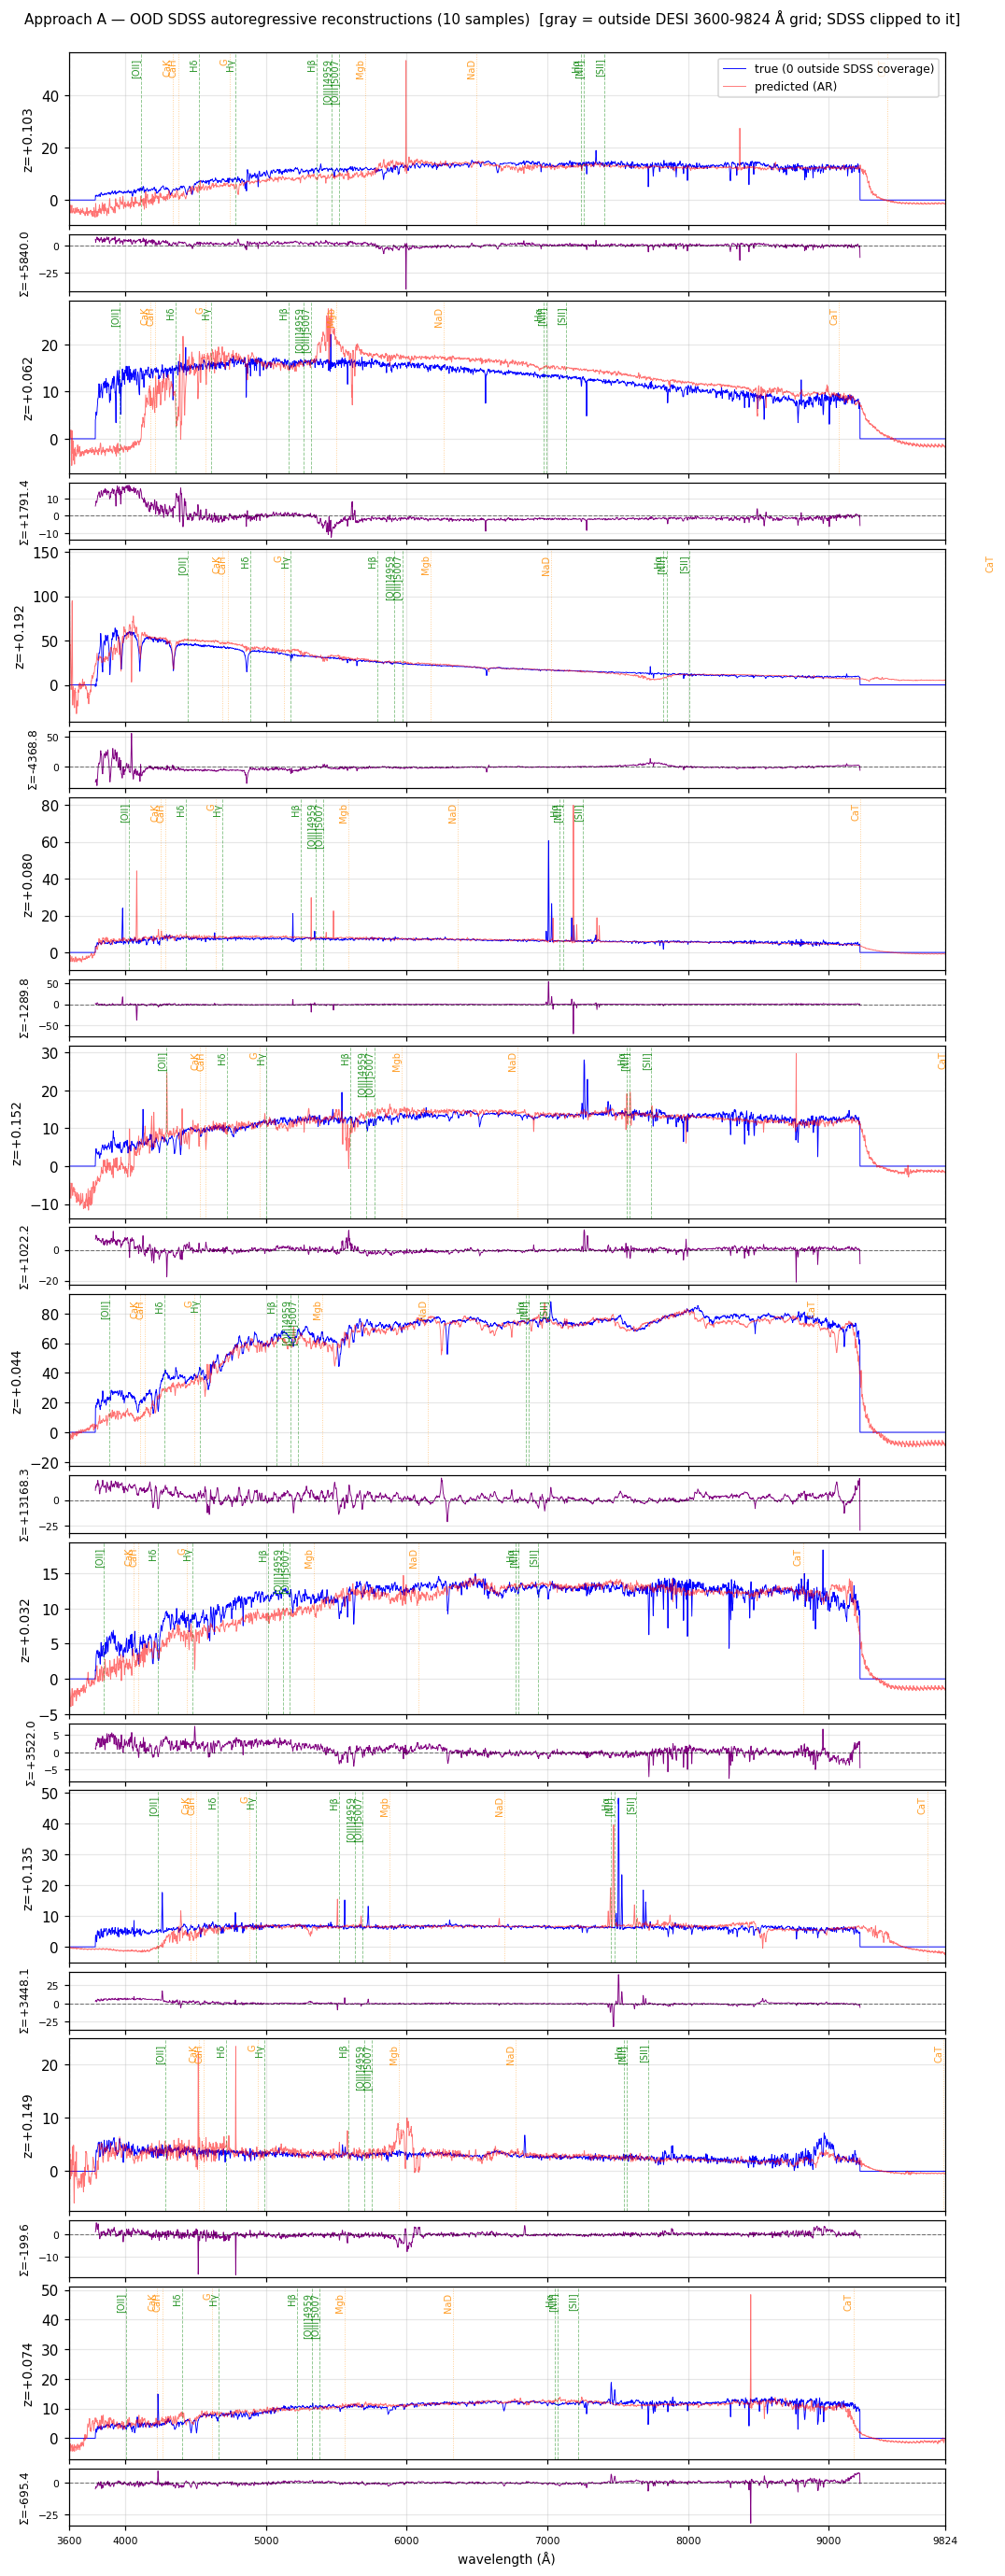

In [14]:
sdss_lo, sdss_hi = float(sdss_wave[0]), float(sdss_wave[-1])

# 2 rows per sample: flux row (height 3) + residual row (height 1)
height_ratios = [h for _ in range(N_OOD) for h in (3, 1)]
fig, axes = plt.subplots(
    N_OOD * 2, 1, figsize=(11, N_OOD * 2.8),
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08},
)

for i in range(N_OOD):
    ax_f = axes[i * 2]      # flux row
    ax_r = axes[i * 2 + 1]  # residual row

    # both arrays are now on the canonical ref_wave grid (LATENT_GRID_SIZE pixels)
    true_s = to_sdss_grid(ood_true_flux[i])
    ar_s   = to_sdss_grid(ood_ar_flux[i])
    resid  = true_s - ar_s
    resid_sum = float(resid.sum())

    # --- flux row ---
    ax_f.plot(ref_wave, ood_true_flux[i], color='blue', lw=0.6,
              label='true (0 outside SDSS coverage)')
    ax_f.plot(ref_wave, ood_ar_flux[i],   color='red',  lw=0.6, alpha=0.55,
              label='predicted (AR)')
    shade_uncovered(ax_f)
    ax_f.axvline(DESI_WAVE_LO, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_f.axvline(DESI_WAVE_HI, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_f.set_ylabel(f'z={ood_specs[i]["z"].item():+.3f}', fontsize=9)
    mark_lines(ax_f, float(ood_specs[i]['z']), GRID_WAVE_MIN, GRID_WAVE_MAX)
    ax_f.set_xticklabels([])
    ax_f.grid(alpha=0.3)
    if i == 0:
        ax_f.legend(loc='upper right', fontsize=8)

    # --- residual row ---
    ax_r.plot(sdss_wave, resid, color='purple', lw=0.6)
    ax_r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    shade_uncovered(ax_r)
    ax_r.set_ylabel(f'$\\Sigma$={resid_sum:+.1f}', fontsize=8, labelpad=4)
    ax_r.grid(alpha=0.3)
    ax_r.tick_params(axis='y', labelsize=7)
    if i < N_OOD - 1:
        ax_r.set_xticklabels([])

axes[-1].set_xlabel('wavelength (Å)', fontsize=9)
# Pull the top axis up to just under the title so the tall figure doesn't
# leave a big white band between the suptitle and the first plot.
fig.subplots_adjust(top=0.97)
fig.suptitle(
    f'Approach {APPROACH.upper()} — OOD SDSS autoregressive reconstructions ({N_OOD} samples)  [gray = outside DESI 3600-9824 Å grid; SDSS clipped to it]',
    y=0.985, fontsize=10,
)
style_wave_axes(fig)
plt.show()


## OOD Visualization 6b — SDSS blind reconstructions (masked encoder + hidden redshift)

The honest test (Viz 2b/2c) applied to **out-of-distribution SDSS**: 50% then 90% of the encoder's spectrum tokens are hidden (`[MASK]`) and the redshift is hidden (`[REDMASK]`). **Orange-shaded** latent regions were hidden from the encoder, so the model must *infer* them — here on data it never trained on. **Gray edges** = outside SDSS wavelength coverage (as in Viz 6).

Compare against the full-encoder SDSS AR panel (Viz 6): on OOD data the cross-attention copy path is already shaky, so the blind gap shows how much the model *generalizes* spectral structure vs. just re-emits the DESI prior. Expect larger residuals than the in-distribution DESI blind panels.


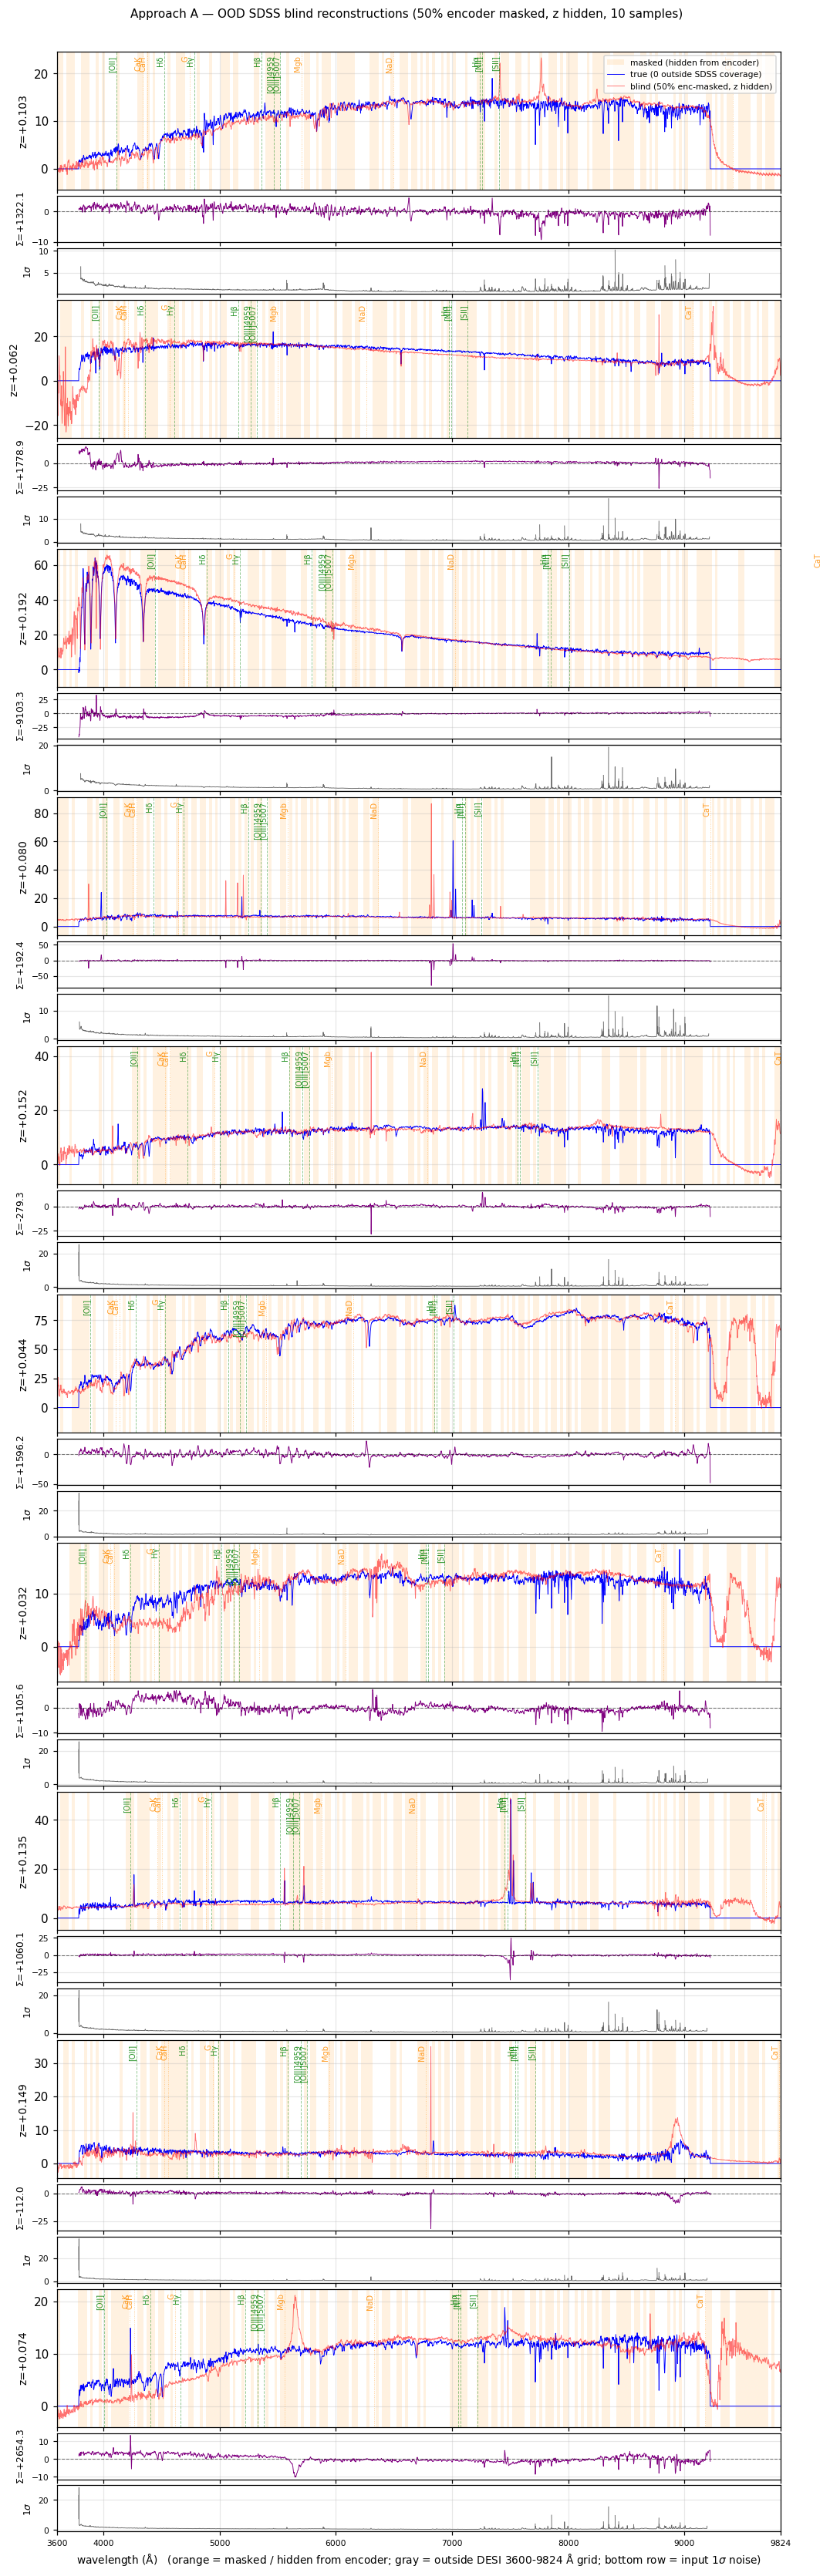

SDSS blind MSE @ 50% masked = 47.2132


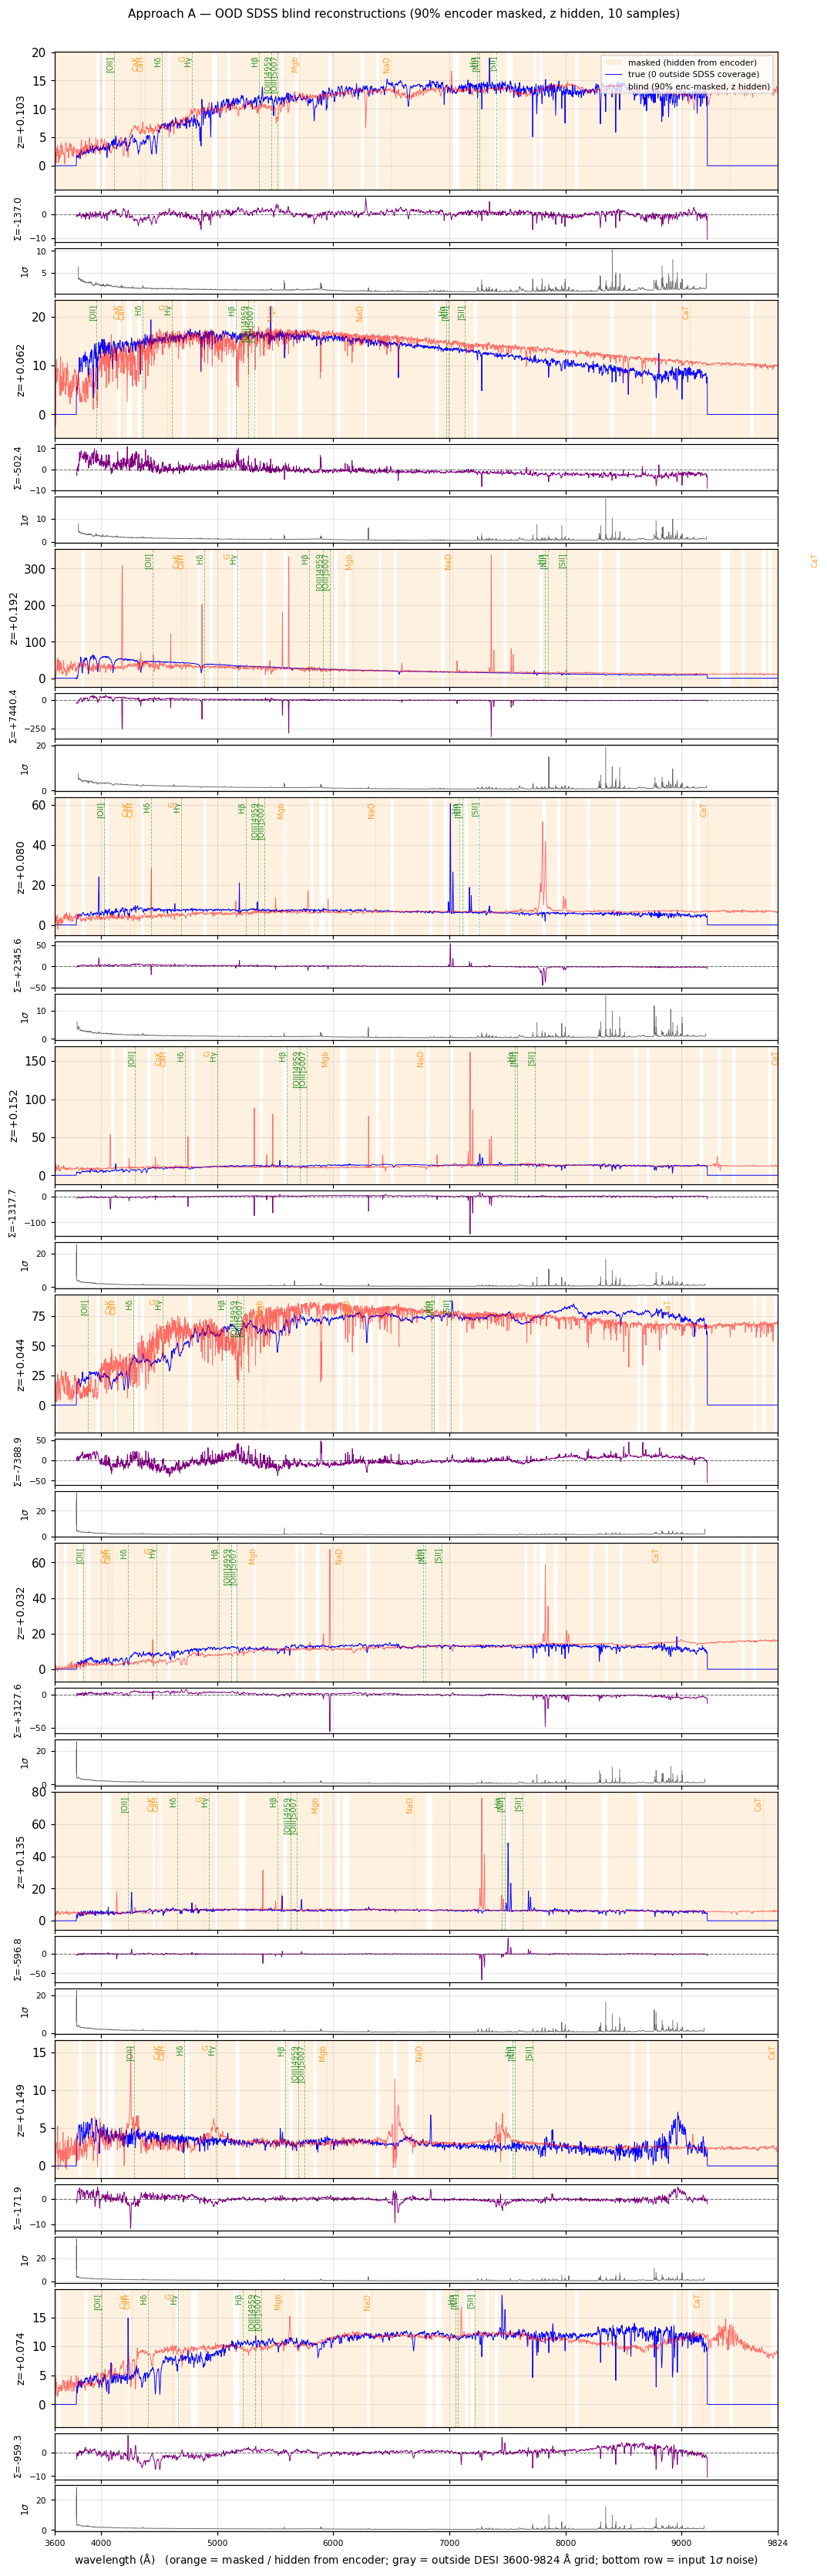

SDSS blind MSE @ 90% masked = 89.8918


In [15]:
# Blind OOD reconstruction at 50% and 90% encoder masking (redshift hidden too).
sdss_lo, sdss_hi = float(sdss_wave[0]), float(sdss_wave[-1])
_L_ood = ood_ar_flux.shape[1]
ood_ivar_np = ood_batch['ivar'].cpu().numpy()   # on the DESI wavelength grid

for _ratio in (0.5, 0.9):
    g, _, m = predict_autoregressive_blind(ood_batch, APPROACH, mask_ratio=_ratio)
    spec_ids = g[:, 2:2 + N_TOKENS]
    if spec_ids.shape[1] < N_TOKENS:
        pad = torch.full((spec_ids.shape[0], N_TOKENS - spec_ids.shape[1]),
                         SPECTRUM_TOKEN_OFFSET, dtype=torch.long, device=device)
        spec_ids = torch.cat([spec_ids, pad], dim=1)
    blind_ood_flux = decode_to_flux(spec_ids, ood_denorm).cpu().numpy()
    mfrac = m.float().mean().item() if m is not None else 0.0

    # token -> ref_wave-pixel map for shading the hidden regions
    m_np = (m.cpu().numpy().astype(bool) if m is not None
            else np.zeros((blind_ood_flux.shape[0], N_TOKENS), bool))
    _n_tok = m_np.shape[1]
    tok_of_x = np.minimum(np.arange(_L_ood) * _n_tok // _L_ood, _n_tok - 1)

    # 3 rows per sample: flux (3) + residual (1) + noise (1)
    height_ratios = [h for _ in range(N_OOD) for h in (3, 1, 1)]
    fig, axes = plt.subplots(
        N_OOD * 3, 1, figsize=(11, N_OOD * 3.4),
        gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08},
    )
    for i in range(N_OOD):
        ax_f = axes[i * 3]      # flux row
        ax_r = axes[i * 3 + 1]  # residual row
        ax_n = axes[i * 3 + 2]  # noise row

        true_s  = to_sdss_grid(ood_true_flux[i])
        blind_s = to_sdss_grid(blind_ood_flux[i])
        resid = true_s - blind_s
        z = float(ood_specs[i]['z'])
        masked_x = m_np[i][tok_of_x]

        # gray coverage spans on every row; orange mask shading on the flux row
        for ax in (ax_f, ax_r, ax_n):
            shade_uncovered(ax)
        ax_f.fill_between(ref_wave, 0, 1, where=masked_x,
                          transform=ax_f.get_xaxis_transform(), step='mid',
                          color='darkorange', alpha=0.12, linewidth=0,
                          label='masked (hidden from encoder)' if i == 0 else None)

        # --- flux row ---
        ax_f.plot(ref_wave, ood_true_flux[i], color='blue', lw=0.6,
                  label='true (0 outside SDSS coverage)')
        ax_f.plot(ref_wave, blind_ood_flux[i], color='red', lw=0.6, alpha=0.55,
                  label=f'blind ({mfrac:.0%} enc-masked, z hidden)')
        ax_f.axvline(DESI_WAVE_LO, color='gray', lw=0.8, ls='--', alpha=0.5)
        ax_f.axvline(DESI_WAVE_HI, color='gray', lw=0.8, ls='--', alpha=0.5)
        ax_f.set_ylabel(f'z={z:+.3f}', fontsize=9)
        mark_lines(ax_f, float(ood_specs[i]['z']), GRID_WAVE_MIN, GRID_WAVE_MAX)
        ax_f.set_xticklabels([])
        ax_f.grid(alpha=0.3)
        if i == 0:
            ax_f.legend(loc='upper right', fontsize=7)

        # --- residual row ---
        ax_r.plot(sdss_wave, resid, color='purple', lw=0.6)
        ax_r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
        ax_r.set_ylabel(f'$\\Sigma$={resid.sum():+.1f}', fontsize=8, labelpad=4)
        ax_r.grid(alpha=0.3)
        ax_r.tick_params(axis='y', labelsize=7)
        ax_r.set_xticklabels([])

        # --- noise row (1-sigma from the SDSS ivar on the DESI grid) ---
        iv = ood_ivar_np[i]
        sig = np.full(iv.shape, np.nan)
        pos = iv > 0
        sig[pos] = 1.0 / np.sqrt(iv[pos])
        ax_n.plot(desi_wave, sig, color='dimgray', lw=0.6)
        ax_n.set_ylabel('1$\\sigma$', fontsize=8, labelpad=4)
        ax_n.grid(alpha=0.3)
        ax_n.tick_params(axis='y', labelsize=7)
        if i < N_OOD - 1:
            ax_n.set_xticklabels([])

    axes[-1].set_xlabel('wavelength (Å)   '
                        '(orange = masked / hidden from encoder; gray = outside DESI 3600-9824 Å grid; '
                        'bottom row = input 1$\\sigma$ noise)',
                        fontsize=9)
    fig.subplots_adjust(top=0.97)
    fig.suptitle(
        f'Approach {APPROACH.upper()} — OOD SDSS blind reconstructions '
        f'({mfrac:.0%} encoder masked, z hidden, {N_OOD} samples)',
        y=0.985, fontsize=10,
    )
    style_wave_axes(fig)
    plt.show()

    blind_ood_mse = ((torch.from_numpy(ood_true_flux) - torch.from_numpy(blind_ood_flux)) ** 2).mean(axis=1)
    print(f'SDSS blind MSE @ {mfrac:.0%} masked = {blind_ood_mse.mean():.4f}')


## OOD Visualization 7 — SDSS redshift prediction

Two series, matching Viz 3:

- **autoregressive (z visible to encoder)** — `ood_generated` ran with `redshift_mask_ratio=0.0`, so for Approach A the true redshift token sits in the encoder and the decoder can copy it via cross-attention. *Copy fidelity, not inference.*
- **blind (z hidden)** — full spectrum visible but the encoder's redshift token is `[REDMASK]` (`predict_autoregressive_blind(..., mask_ratio=0.0)`). This is the **honest spectrum→z** number: it tests whether OOD SDSS spectral features are recognisable enough to recover the redshift with no z hint. This is the one that matters.

For Approach B the encoder never carries a redshift token, so the two series coincide.


2026-06-23 21:46:44.653 python[10089:33575119] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-10089-2026-06-23_21_46_44-2306922936‚Äù because the volume ‚ÄúMacintosh HD‚Äù is out of space.
2026-06-23 21:46:55.115 python[10089:33575119] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-10089-2026-06-23_21_46_55-3979222157‚Äù because the volume ‚ÄúMacintosh HD‚Äù is out of space.
2026-06-23 21:46:55.729 python[10089:33575119] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-10089-2026-06-23_21_46_55-2901233273‚Äù because the volume ‚ÄúMacintosh HD‚Äù is out of space.
2026-06-23 21:46:55.733 python[10089:33575119] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-10089-2026-06-23_21_46_55-3289899997‚Äù because the volume ‚ÄúMacintosh HD‚Äù i

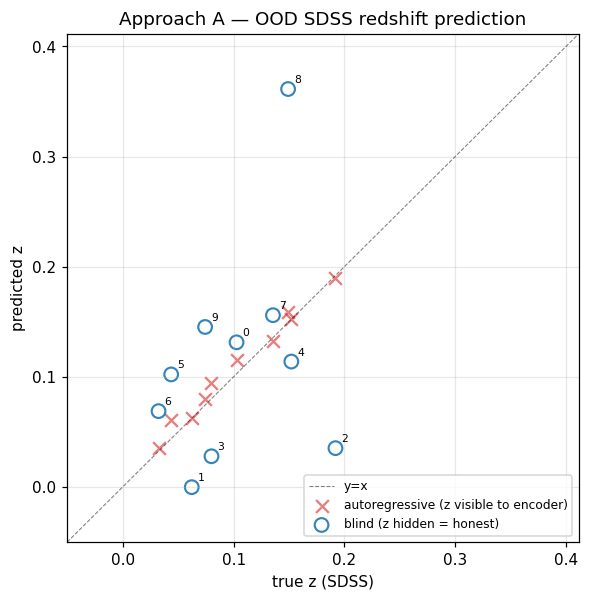

OOD SDSS — autoregressive   MAE = 0.0066  (z copied from encoder)
OOD SDSS — blind (z hidden) MAE = 0.0737  <- honest spectrum->z

  0: z_true=+0.1026  ar=+0.1148  blind=+0.1312
  1: z_true=+0.0622  ar=+0.0627  blind=-0.0004
  2: z_true=+0.1919  ar=+0.1900  blind=+0.0351
  3: z_true=+0.0800  ar=+0.0944  blind=+0.0277
  4: z_true=+0.1521  ar=+0.1520  blind=+0.1137
  5: z_true=+0.0436  ar=+0.0602  blind=+0.1021
  6: z_true=+0.0322  ar=+0.0351  blind=+0.0687
  7: z_true=+0.1355  ar=+0.1329  blind=+0.1559
  8: z_true=+0.1492  ar=+0.1588  blind=+0.3613
  9: z_true=+0.0743  ar=+0.0794  blind=+0.1452


In [16]:
ood_z_true = torch.stack([s['z'] for s in ood_specs]).float()

# Copy path: z was visible in the encoder (Approach A) -> cross-attention copy.
ood_ar_z_token = ood_generated[:, 1].cpu()
ood_ar_z_idx   = (ood_ar_z_token - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
ood_ar_z_pred  = torch.tensor([z_tok.decode(int(i)) for i in ood_ar_z_idx])

# Honest path: full spectrum visible, redshift hidden ([REDMASK]) -> spectrum->z.
ood_blindz_generated, _, _ = predict_autoregressive_blind(ood_batch, APPROACH, mask_ratio=0.0)
ood_blind_z_token = ood_blindz_generated[:, 1].cpu()
ood_blind_z_idx   = (ood_blind_z_token - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
ood_blind_z_pred  = torch.tensor([z_tok.decode(int(i)) for i in ood_blind_z_idx])

fig, ax = plt.subplots(figsize=(6, 6))
_all = torch.cat([ood_z_true, ood_ar_z_pred, ood_blind_z_pred])
lim_lo = _all.min().item() - 0.05
lim_hi = _all.max().item() + 0.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=0.7, alpha=0.5, label='y=x')
ax.scatter(ood_z_true, ood_ar_z_pred, s=70, alpha=0.6, marker='x',
           label='autoregressive (z visible to encoder)', c='C3')
ax.scatter(ood_z_true, ood_blind_z_pred, s=80, alpha=0.9, marker='o', facecolors='none',
           edgecolors='C0', linewidths=1.4, label='blind (z hidden = honest)')
for i in range(len(ood_z_true)):
    ax.annotate(str(i), (ood_z_true[i], ood_blind_z_pred[i]), fontsize=7,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('true z (SDSS)')
ax.set_ylabel('predicted z')
ax.set_title(f'Approach {APPROACH.upper()} — OOD SDSS redshift prediction')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
plt.show()

print(f'OOD SDSS — autoregressive   MAE = {(ood_ar_z_pred - ood_z_true).abs().mean():.4f}  (z copied from encoder)')
print(f'OOD SDSS — blind (z hidden) MAE = {(ood_blind_z_pred - ood_z_true).abs().mean():.4f}  <- honest spectrum->z')
print()
for i in range(len(ood_z_true)):
    print(f'  {i}: z_true={ood_z_true[i]:+.4f}  ar={ood_ar_z_pred[i]:+.4f}  blind={ood_blind_z_pred[i]:+.4f}')


## OOD Visualization 8 — SDSS vs DESI AR MSE comparison

AR MSE histogram comparing in-distribution DESI reconstructions against OOD SDSS. Higher SDSS MSE is expected — the gap measures how domain-specific the tokenizer + transformer representation is.

In [ ]:
# Project both onto the common SDSS grid before computing MSE
ood_true_on_sdss = np.stack([to_sdss_grid(ood_true_flux[i]) for i in range(N_OOD)])
ood_ar_on_sdss   = np.stack([to_sdss_grid(ood_ar_flux[i])   for i in range(N_OOD)])
ood_ar_mse = ((ood_true_on_sdss - ood_ar_on_sdss)**2).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ar_mse,     bins=15, alpha=0.6, label=f'DESI AR (mean={ar_mse.mean():.3f})',     color='C1')
ax.hist(ood_ar_mse, bins=15, alpha=0.6, label=f'SDSS AR (mean={ood_ar_mse.mean():.3f})', color='C0')
ax.set_xlabel('per-spectrum MSE (autoregressive)')
ax.set_ylabel('count')
ax.set_title('OOD degradation: SDSS vs DESI \u2014 autoregressive MSE')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f'DESI AR MSE : mean={ar_mse.mean():.3f}')
print(f'SDSS AR MSE : mean={ood_ar_mse.mean():.3f}  ({ood_ar_mse.mean()/max(ar_mse.mean(),1e-9):.1f}x vs DESI)')


---
## Redshift from the FULL spectrum (no masking) — the foundation-model deliverable

The masking during *training* was a means to an end: it taught the model spectral features and their link to redshift. The actual test of a spectrum foundation model is the instructor's point — **given a full observed spectrum (all of it, no masking), how well does it measure the redshift?**

Here the encoder sees the **entire spectrum** (`encoder_mask_ratio=0.0`); only the redshift token is hidden (`[REDMASK]`), because that is the quantity being predicted (you can't hand the model the answer). Redshift is decoder position 0, so a single decode step from `[SOS]` recovers it — no autoregression — which is fast enough to run over the whole sample.

- **DESI** (in-distribution): the **entire** set of good spectra loaded above.
- **SDSS** (out-of-distribution): a fresh stream of **100** spectra (the reconstruction panels stay at `N_OOD` rows for legibility).

**Metrics** (on Δz/(1+z)):
- **NMAD** = 1.4826·median(|Δz/(1+z) − median|) — robust scatter.
- **Catastrophic outlier fraction** = fraction with |Δz|/(1+z) above a threshold.
- **Bin-resolution floor**: with 256 z-levels the quantization step is a hard NMAD floor; the finer z-head (X3, 4096 bins) is what lets it go lower.

> Note: DESI here uses the spectra loaded earlier in the notebook. For a strict held-out number, run on the training validation split on NERSC — these tiles may overlap training.


In [11]:
@torch.no_grad()
def predict_redshift_fullspec(batch, approach):
    """Measure redshift from the FULL spectrum with NO spectrum masking: the
    encoder sees every spectrum token (encoder_mask_ratio=0.0); only the redshift
    is hidden ([REDMASK]) since it is the quantity being predicted. Redshift is
    decoder position 0, so one decode step from [SOS] suffices (no autoregression).
    Returns (z_pred, z_true) as 1-D CPU tensors."""
    enc, _, _, _ = tokenize_and_build(
        batch, spec_tok, z_tok, approach, device,
        wavelength_aware=WAVELENGTH_AWARE,
        encoder_mask_ratio=0.0,
        redshift_mask_ratio=(1.0 if approach == 'a' else 0.0),
    )
    sos = torch.full((enc.shape[0], 1), SOS_TOKEN, dtype=torch.long, device=device)
    logits, _ = model(enc, sos)                 # logits[:, 0] predicts the redshift token
    z_ids = logits[:, 0].argmax(dim=-1).cpu()
    z_bin = (z_ids - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
    z_pred = torch.tensor([z_tok.decode(int(b)) for b in z_bin])
    return z_pred, batch['z'].float().cpu()


@torch.no_grad()
def eval_redshift(spec_list, approach, batch_size=64):
    """Batched redshift prediction over a list of spectrum dicts."""
    zp, zt = [], []
    for s in range(0, len(spec_list), batch_size):
        b = specs_to_batch(spec_list[s:s + batch_size])
        p, t = predict_redshift_fullspec(b, approach)
        zp.append(p); zt.append(t)
    return torch.cat(zp), torch.cat(zt)


def redshift_metrics(z_pred, z_true):
    dz = z_pred - z_true
    norm = dz / (1.0 + z_true)
    nmad = (1.4826 * (norm - norm.median()).abs().median()).item()
    return {
        'N': len(z_true),
        'MAE': dz.abs().mean().item(),
        'median_dz_over_1pz': norm.median().item(),
        'NMAD': nmad,
        'outlier_gt_0.003': (norm.abs() > 0.003).float().mean().item(),
        'outlier_gt_0.01': (norm.abs() > 0.01).float().mean().item(),
    }, norm


def print_metrics(tag, m):
    print(f'{tag} — full spectrum, redshift hidden:')
    for k, v in m.items():
        print(f'  {k:20s} = {v}' if k == 'N' else f'  {k:20s} = {v:.5f}')


def plot_redshift(z_true, z_pred, norm, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    lo = min(z_true.min().item(), z_pred.min().item()) - 0.05
    hi = max(z_true.max().item(), z_pred.max().item()) + 0.05
    ax1.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5, label='y=x')
    ax1.scatter(z_true, z_pred, s=12, alpha=0.4, c='C0', edgecolors='none')
    ax1.set_xlabel('true z'); ax1.set_ylabel('predicted z (full spectrum, z hidden)')
    ax1.set_xlim(lo, hi); ax1.set_ylim(lo, hi)
    ax1.set_title(title); ax1.grid(alpha=0.3); ax1.legend()
    ax2.hist(norm.numpy(), bins=60, color='C0', alpha=0.8)
    ax2.axvline(0, color='k', lw=0.8, ls='--', alpha=0.6)
    ax2.set_xlabel(r'$\Delta z / (1+z)$'); ax2.set_ylabel('count')
    ax2.set_title('redshift error distribution'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


_zbw = (z_tok._max_z - z_tok._min_z) / z_tok.n_levels
print(f'z quantization: {z_tok.n_levels} bins over z=[{z_tok._min_z:.3f}, {z_tok._max_z:.3f}]  '
      f'-> bin width ~{_zbw:.5f} (hard resolution floor; X3 4096 bins shrinks this)')


z quantization: 4096 bins over z=[-0.004, 5.995]  -> bin width ~0.00146 (hard resolution floor; X3 4096 bins shrinks this)


DESI (in-distribution) — full spectrum, redshift hidden:
  N                    = 29
  MAE                  = 0.02628
  median_dz_over_1pz   = -0.00001
  NMAD                 = 0.00043
  outlier_gt_0.003     = 0.06897
  outlier_gt_0.01      = 0.03448


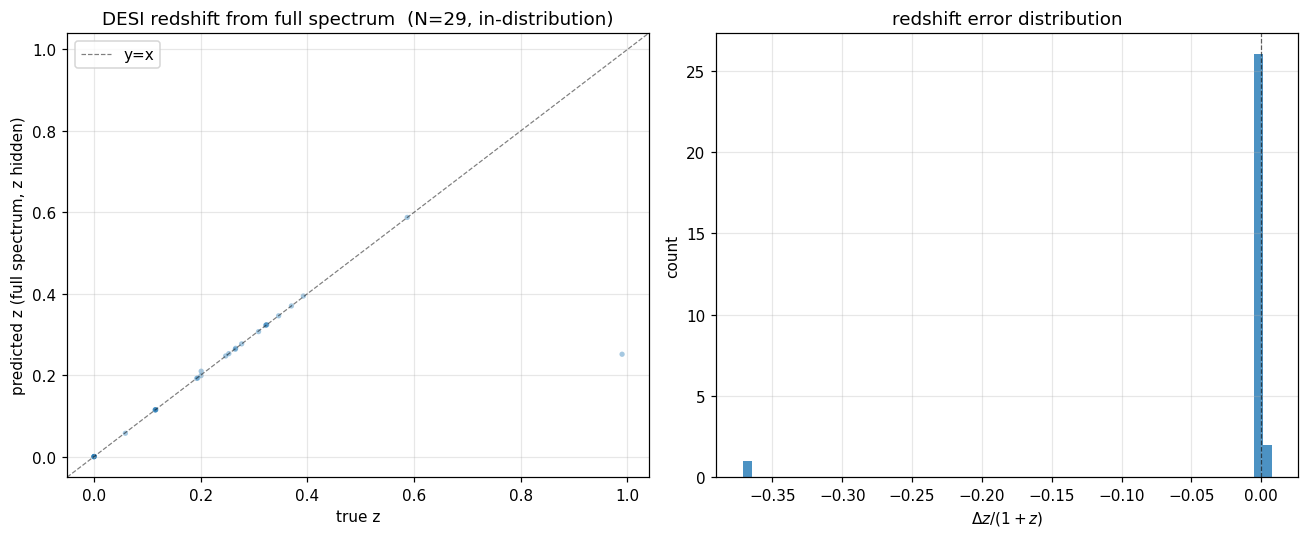

In [18]:
# DESI (in-distribution): the ENTIRE local sample, full spectrum, redshift hidden.
desi_zp, desi_zt = eval_redshift(spectra, APPROACH)
desi_m, desi_norm = redshift_metrics(desi_zp, desi_zt)
print_metrics('DESI (in-distribution)', desi_m)
plot_redshift(desi_zt, desi_zp, desi_norm,
              f'DESI redshift from full spectrum  (N={desi_m["N"]}, in-distribution)')


SDSS redshift eval on 100 spectra (pool from the OOD load cell)
SDSS (out-of-distribution) — full spectrum, redshift hidden:
  N                    = 100
  MAE                  = 0.17001
  median_dz_over_1pz   = 0.00050
  NMAD                 = 0.02945
  outlier_gt_0.003     = 0.70000
  outlier_gt_0.01      = 0.55000


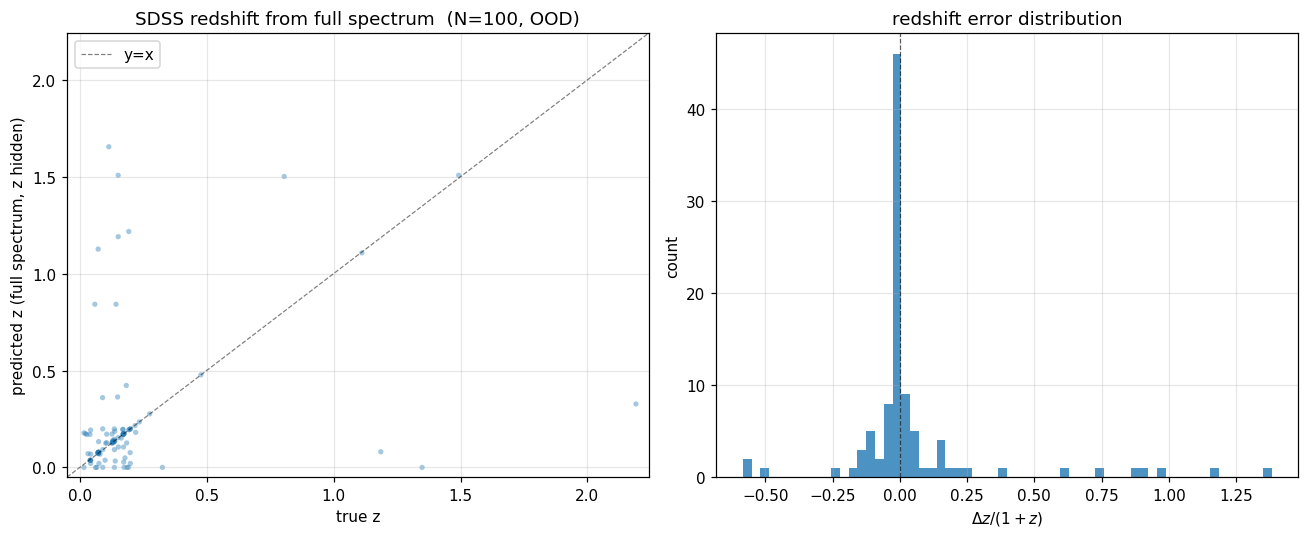

In [14]:
# SDSS (out-of-distribution): reuse the pool streamed in the SDSS-load cell
# (avoids a second, flaky stream). resample_sdss is defined in the OOD section.
sdss_z_specs = [resample_sdss(r) for r in sdss_pool]
print(f'SDSS redshift eval on {len(sdss_z_specs)} spectra (pool from the OOD load cell)')

sdss_zp, sdss_zt = eval_redshift(sdss_z_specs, APPROACH)
sdss_m, sdss_norm = redshift_metrics(sdss_zp, sdss_zt)
print_metrics('SDSS (out-of-distribution)', sdss_m)
plot_redshift(sdss_zt, sdss_zp, sdss_norm,
              f'SDSS redshift from full spectrum  (N={sdss_m["N"]}, OOD)')


## What to look for

| signal | interpretation |
|---|---|
| TF and AR reconstructions look similar | model has actually learned spectroscopy |
| TF looks great, AR looks like noise | the teacher-forced number was inflated by the cross-attention copy — the model can't actually generate |
| Redshift scatter on `y=x` for Approach A | cross-attention copy works (expected) |
| Redshift scatter scattered for Approach B | the encoder isn't encoding redshift (the Phase 9 result) |
| Per-position accuracy flat-high for pos 1+, low at pos 0 | classic copy regime — needs encoder masking |
| Per-position accuracy declining toward the end of the sequence | error accumulation in AR, typical of language models |
| AR/TF MSE ratio = 1.0 | honest model |
| AR/TF MSE ratio >>1 (e.g. 10x+) | strong copy dependency |